In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from src.models import SIRM, SIRT, SIRV
from helps import *

In [36]:
temp = read_json("./parameters.json")
mus, taus, xis, PARAMS = temp["mus"], temp["taus"], temp["xis"], temp["PARAMS"]
rect_coords_M = [mus["pol"][0], mus["h"][0], mus["pol"][2]-mus["pol"][0], mus["h"][2]-mus["h"][0]]
rect_coords_T = [taus["pol"][0], taus["h"][0], taus["pol"][2]-taus["pol"][0], taus["h"][2]-taus["h"][0]]
rect_coords_V = [xis["pol"][0], xis["h"][0], xis["pol"][2]-xis["pol"][0], xis["h"][2]-xis["h"][0]]

In [37]:
betas = np.linspace(0.15, 0.4, 25)
NB = 50
NP = 50
homophilic_tendency = {"m": 0, "M": 6, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}
PS = 10
PARAMS["fixed_mean"] = 0.5
# visualization parameters

colors_X = ['#66c2a4', '#238b45','#00441b']  # fixed polarization
colors_Y = ['#67001f', '#e7298a', '#df65b0'] # fixed homophily
my_map = discretize_cmaps("hot_r",51)
my_map.set_bad(color='gray')
cmaps = [my_map]
contour_values = [[0.2, 0.4, 0.6, 0.8]]
contour_colors = [['#000','#000','#000']]
final_params={
        'Lx': Lx/1.25,  # Figure width in inches
        'Ly': Ly/1.25,  # Figure height in inches
        'xticks': [0, 0.5, 1.0],
        'yticks': [0, 10, 20],
        'xlim': [0, 1],
        'ylim': [0, 20]
    }

In [38]:
print("### SIR-M ###")
PS = 20
res_list_M = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_M.append(M)
    print(f"Completed beta_M = {b}")

print("### SIR-T ###")
res_list_T = []

for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRT,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_T.append(M)
    print(f"Completed beta_M = {b}")

print("### SIR-V ###")
res_list_V = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRV,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_V.append(M)
    print(f"Completed beta_M = {b}")

### SIR-M ###
Completed beta_M = 0.15
Completed beta_M = 0.16041666666666665
Completed beta_M = 0.17083333333333334
Completed beta_M = 0.18125
Completed beta_M = 0.19166666666666665
Completed beta_M = 0.20208333333333334
Completed beta_M = 0.2125
Completed beta_M = 0.22291666666666665
Completed beta_M = 0.23333333333333334
Completed beta_M = 0.24375
Completed beta_M = 0.25416666666666665
Completed beta_M = 0.26458333333333334
Completed beta_M = 0.275
Completed beta_M = 0.28541666666666665
Completed beta_M = 0.2958333333333333
Completed beta_M = 0.30625
Completed beta_M = 0.31666666666666665
Completed beta_M = 0.3270833333333333
Completed beta_M = 0.3375
Completed beta_M = 0.34791666666666665
Completed beta_M = 0.3583333333333333
Completed beta_M = 0.36875
Completed beta_M = 0.37916666666666665
Completed beta_M = 0.3895833333333333
Completed beta_M = 0.4
### SIR-T ###
Completed beta_M = 0.15
Completed beta_M = 0.16041666666666665
Completed beta_M = 0.17083333333333334
Completed beta_M =

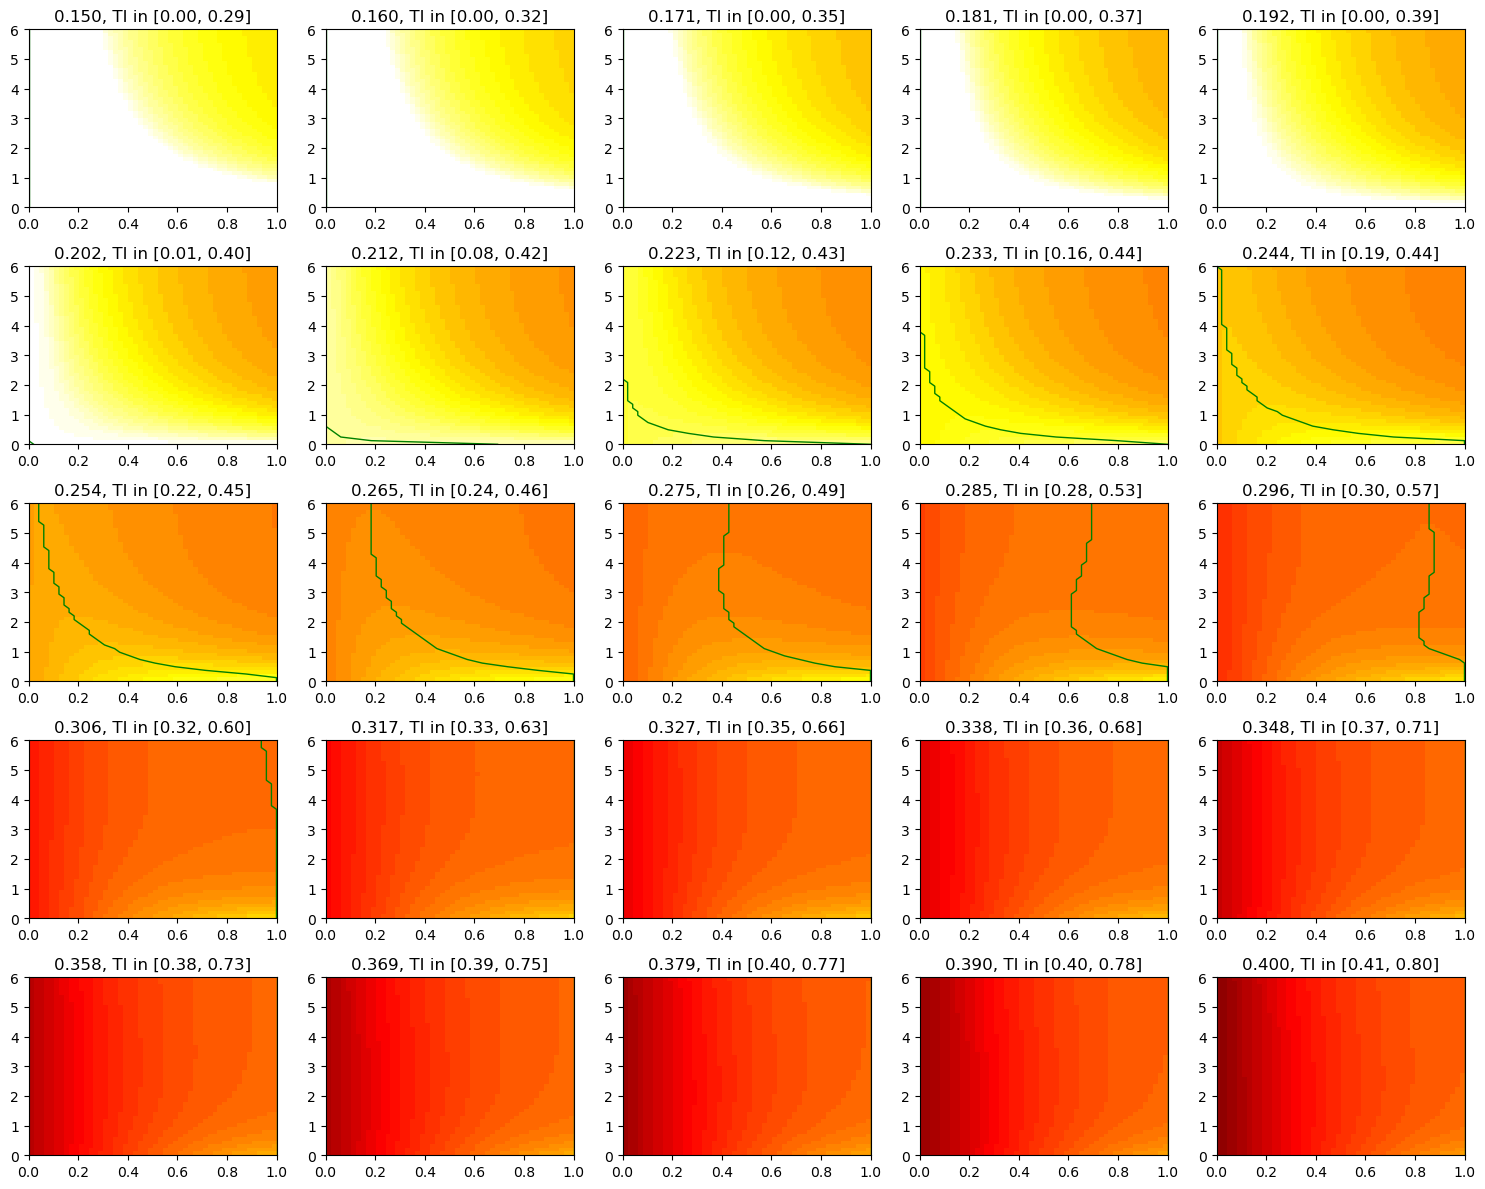

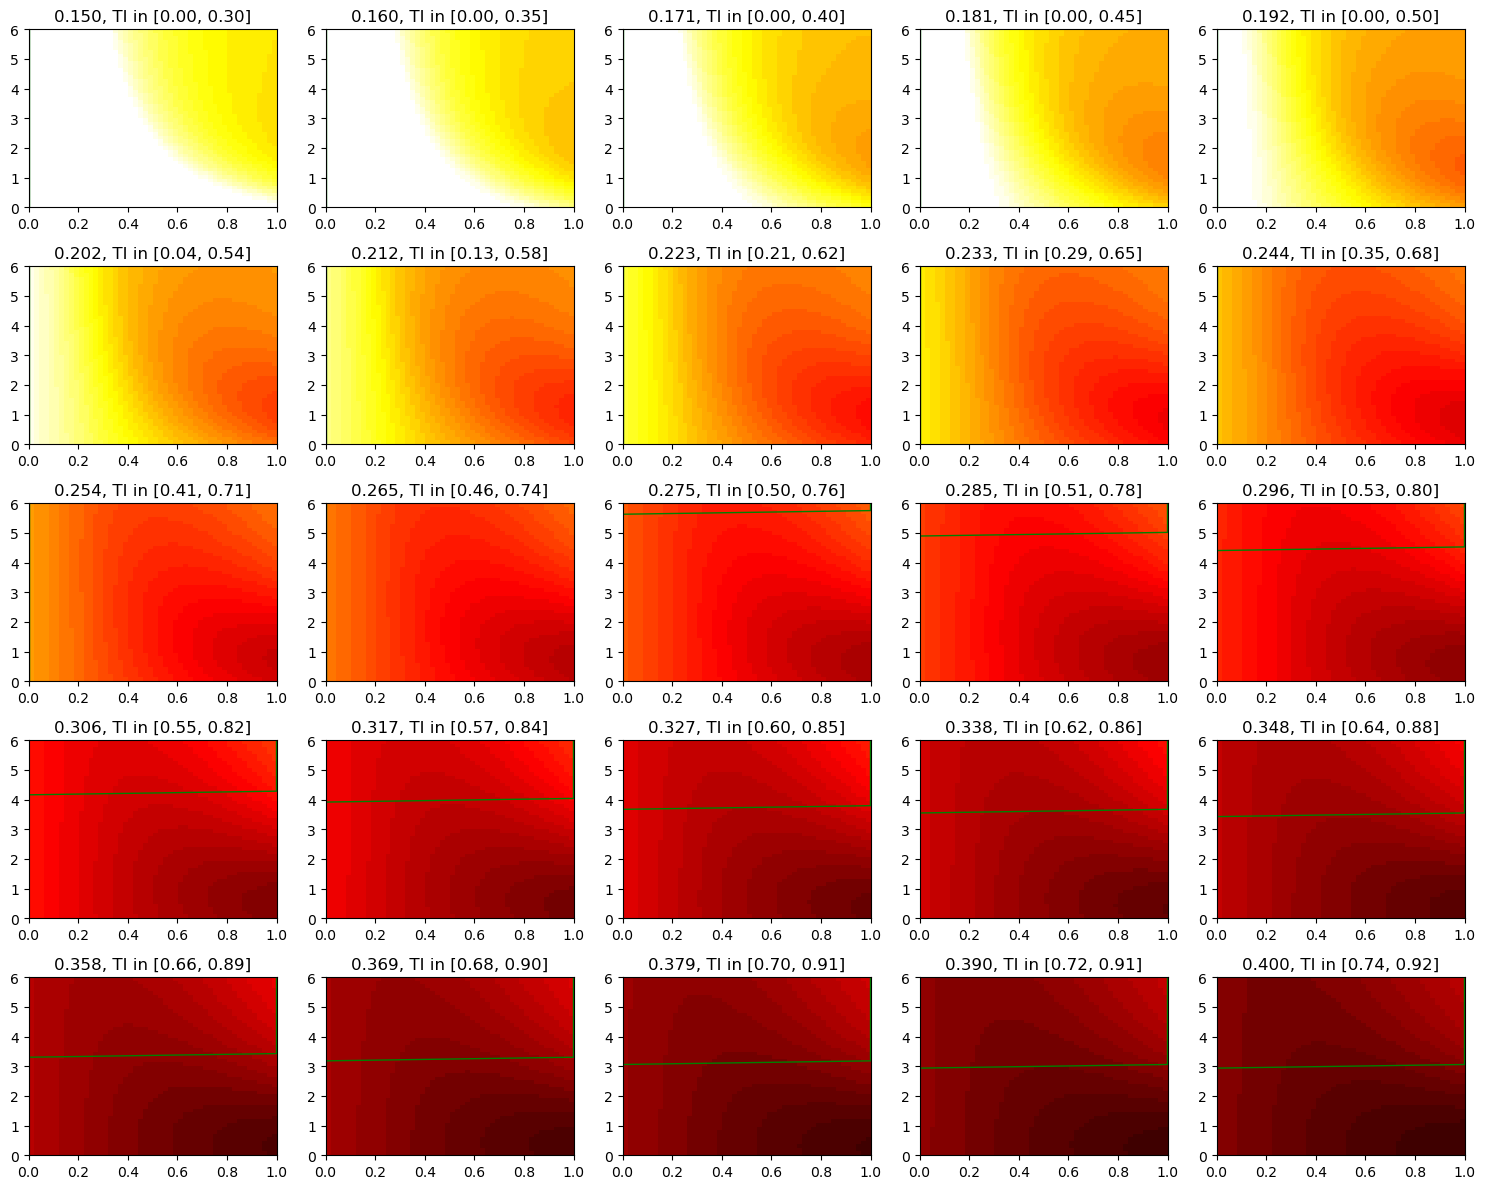

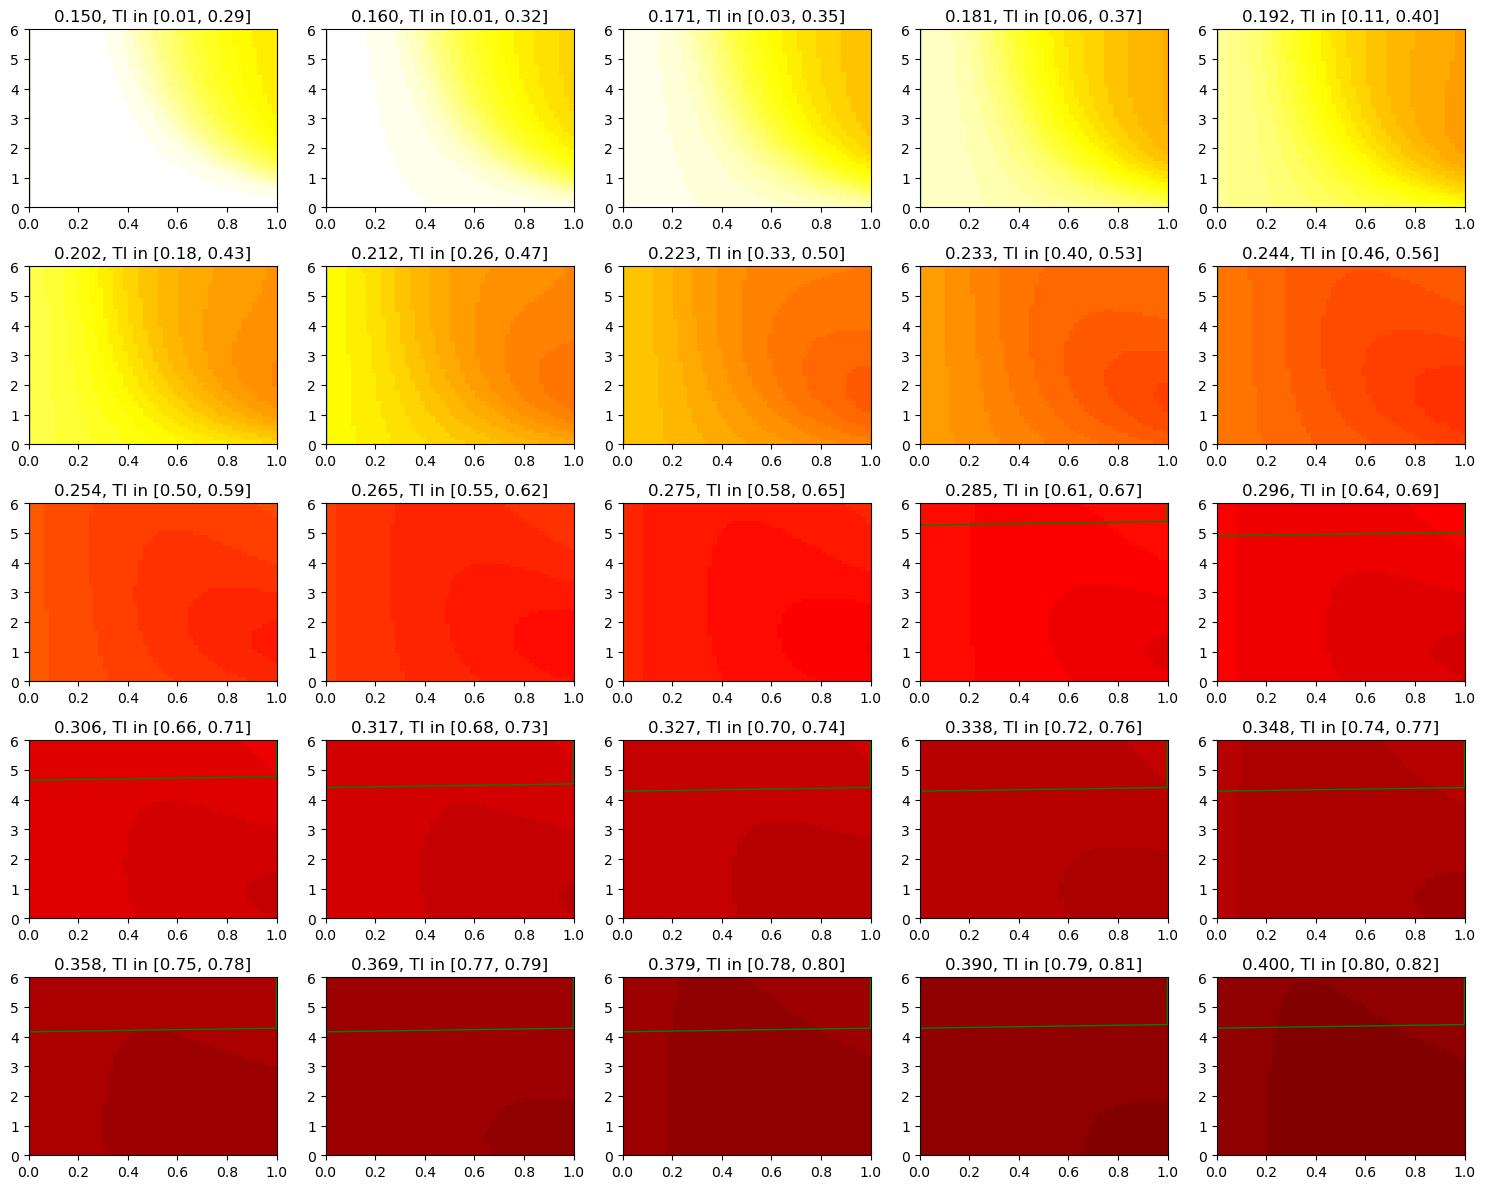

In [39]:
plot_25(res_list_M)
plot_25(res_list_T)
plot_25(res_list_V)

In [40]:
betas = [0.15, 0.2, 0.3]
print("### SIR-M ###")
PS = 20
res_list_M = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_M.append(M)
    print(f"Completed beta_M = {b}")

print("### SIR-T ###")
res_list_T = []

for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRT,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_T.append(M)
    print(f"Completed beta_M = {b}")

print("### SIR-V ###")
res_list_V = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRV,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_V.append(M)
    print(f"Completed beta_M = {b}")


### SIR-M ###
Completed beta_M = 0.15
Completed beta_M = 0.2
Completed beta_M = 0.3
### SIR-T ###
Completed beta_M = 0.15
Completed beta_M = 0.2
Completed beta_M = 0.3
### SIR-V ###
Completed beta_M = 0.15
Completed beta_M = 0.2
Completed beta_M = 0.3


In [2]:
temp = read_json("./parameters_novariability.json")
mus, taus, xis, PARAMS = temp["mus"], temp["taus"], temp["xis"], temp["PARAMS"]
rect_coords_M = [mus["pol"][0], mus["h"][0], mus["pol"][2]-mus["pol"][0], mus["h"][2]-mus["h"][0]]
rect_coords_T = [taus["pol"][0], taus["h"][0], taus["pol"][2]-taus["pol"][0], taus["h"][2]-taus["h"][0]]
rect_coords_V = [xis["pol"][0], xis["h"][0], xis["pol"][2]-xis["pol"][0], xis["h"][2]-xis["h"][0]]

In [3]:
betas = np.linspace(0.15, 0.4, 25)
NB = 50
NP = 50
homophilic_tendency = {"m": 0, "M": 6, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}
PS = 10
PARAMS["fixed_mean"] = 0.5
# visualization parameters

colors_X = ['#66c2a4', '#238b45','#00441b']  # fixed polarization
colors_Y = ['#67001f', '#e7298a', '#df65b0'] # fixed homophily
my_map = discretize_cmaps("hot_r",51)
my_map.set_bad(color='gray')
cmaps = [my_map]
contour_values = [[0.2, 0.4, 0.6, 0.8]]
contour_colors = [['#000','#000','#000']]
final_params={
        'Lx': Lx/1.25,  # Figure width in inches
        'Ly': Ly/1.25,  # Figure height in inches
        'xticks': [0, 0.5, 1.0],
        'yticks': [0, 10, 20],
        'xlim': [0, 1],
        'ylim': [0, 20]
    }

In [4]:
# plot all of them in one figure

def plot_25(res_list):
    fig, axes = plt.subplots(5, 5, figsize=(15, 12))
    for i, ax in enumerate(axes.flatten()):
        TI = np.sum(res_list[i]["final_state"]["I"] + res_list[i]["final_state"]["R"], axis=2)

        im = ax.imshow(
            TI, vmin = 0, vmax = 1, cmap = my_map,
            origin='lower', extent=[0, 1, 0, 6],
            aspect='auto')
        ax.set_title(f"{betas[i]:.3f}, TI in [{TI.min():.2f}, {TI.max():.2f}]")
        
        # Find minimum polarization for each homophily level
        min_pol_curve = []
        homophily_values = []
        
        for h_idx in range(TI.shape[0]):  # iterate over homophily axis (rows)
            # Find minimum polarization index for this homophily level
            pol_idx = np.nanargmin(TI[h_idx, :])
            
            # Convert indices to actual values
            min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (pol_idx / (pol_range["n"] - 1))
            homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (h_idx / (homophilic_tendency["n"] - 1))
            
            min_pol_curve.append(min_pol)
            homophily_values.append(homophily)
        
        # Plot the curve
        ax.plot(min_pol_curve, homophily_values, color="green", linewidth=1)

    fig.tight_layout()

In [34]:
print("### SIR-M ###")
PS = 10
res_list_M = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_M.append(M)
    print(f"Completed beta_M = {b}")

### SIR-M ###
Completed beta_M = 0.15
Completed beta_M = 0.16041666666666665
Completed beta_M = 0.17083333333333334
Completed beta_M = 0.18125
Completed beta_M = 0.19166666666666665
Completed beta_M = 0.20208333333333334
Completed beta_M = 0.2125
Completed beta_M = 0.22291666666666665
Completed beta_M = 0.23333333333333334
Completed beta_M = 0.24375
Completed beta_M = 0.25416666666666665
Completed beta_M = 0.26458333333333334
Completed beta_M = 0.275
Completed beta_M = 0.28541666666666665
Completed beta_M = 0.2958333333333333
Completed beta_M = 0.30625
Completed beta_M = 0.31666666666666665
Completed beta_M = 0.3270833333333333
Completed beta_M = 0.3375
Completed beta_M = 0.34791666666666665
Completed beta_M = 0.3583333333333333
Completed beta_M = 0.36875
Completed beta_M = 0.37916666666666665
Completed beta_M = 0.3895833333333333
Completed beta_M = 0.4


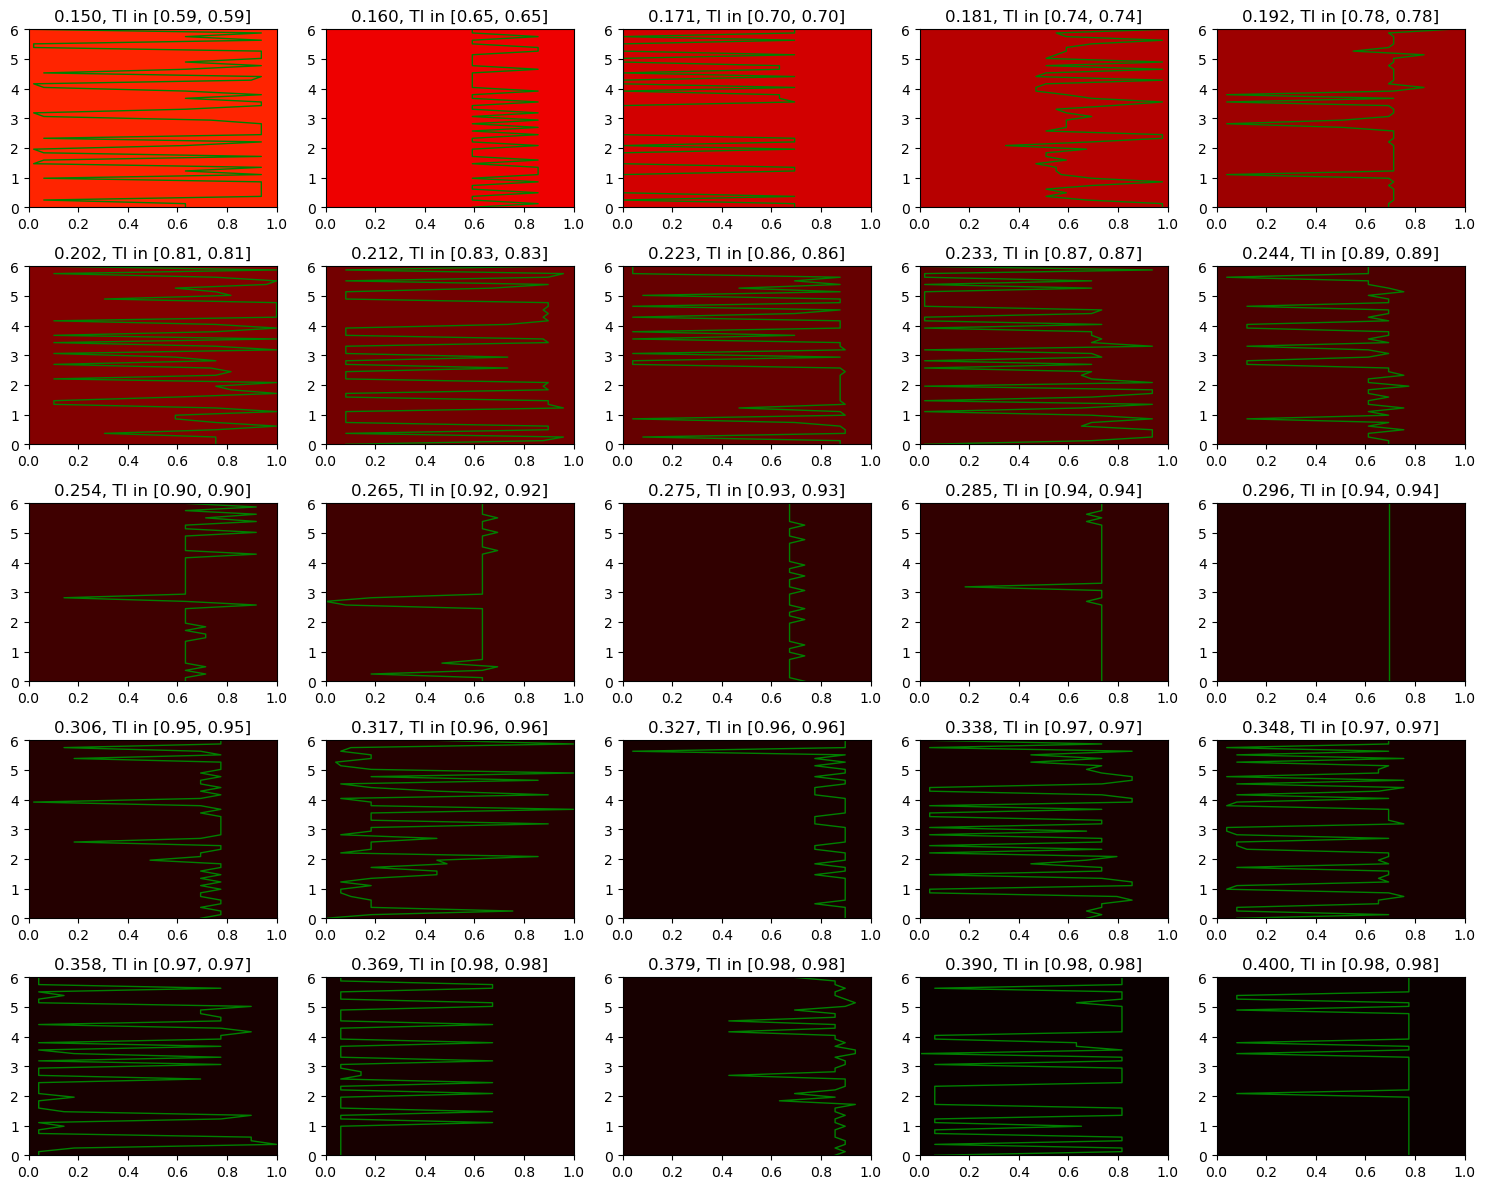

In [35]:
plot_25(res_list_M)

In [ ]:
def normalize(M,pop):
    return M / (M @ pop)[:, None]

def create_contact_matrix_ABC(n_groups, homophilic_tendency, group_sizes, Cm_external = None, norm = True):
    if Cm_external is None:
        positions = np.linspace(0, 1, n_groups)
        diffs = np.abs(positions[:, None] - positions[None, :])
        weights = np.exp(-homophilic_tendency * diffs)
        C = weights  * n_groups * n_groups
    else:
        C = Cm_external.copy()
    if norm:
        C = normalize(C, group_sizes)
        TC = np.sum(np.outer(group_sizes, group_sizes) * C) # Total contacts
        C = C / TC # Normalize to total contacts
    
    return C

In [33]:
from scipy.stats import beta
import numpy as np
a = 0.44
b = 0.44

NC = 5
x = np.linspace(0+1/NC/2, 1-1/NC/2, NC)
y = beta.pdf(x, a, b)
y = y / np.sum(y)
C = create_contact_matrix_ABC(NC, 6, y)



# how many contacts a person from group i makes?

print(C @ y)

[1. 1. 1. 1. 1.]


[[3.72069474 1.91026837 0.98076448 0.50354128 0.25852671 0.13273204
  0.0681469  0.03498779 0.01796333 0.00922268]
 [1.88766952 3.67667818 1.88766952 0.96916185 0.49758428 0.25546829
  0.13116179 0.06734071 0.03457387 0.01775082]
 [1.02987849 2.00592938 3.90701694 2.00592938 1.02987849 0.52875724
  0.27147302 0.1393789  0.07155951 0.03673988]
 [0.56069551 1.09208574 2.12709257 4.14301061 2.12709257 1.09208574
  0.56069551 0.28787068 0.14779773 0.07588189]
 [0.29758959 0.57962537 1.12895607 2.19890617 4.2828844  2.19890617
  1.12895607 0.57962537 0.29758959 0.15278759]
 [0.15278759 0.29758959 0.57962537 1.12895607 2.19890617 4.2828844
  2.19890617 1.12895607 0.57962537 0.29758959]
 [0.07588189 0.14779773 0.28787068 0.56069551 1.09208574 2.12709257
  4.14301061 2.12709257 1.09208574 0.56069551]
 [0.03673988 0.07155951 0.1393789  0.27147302 0.52875724 1.02987849
  2.00592938 3.90701694 2.00592938 1.02987849]
 [0.01775082 0.03457387 0.06734071 0.13116179 0.25546829 0.49758428
  0.96916185 

<BarContainer object of 10 artists>

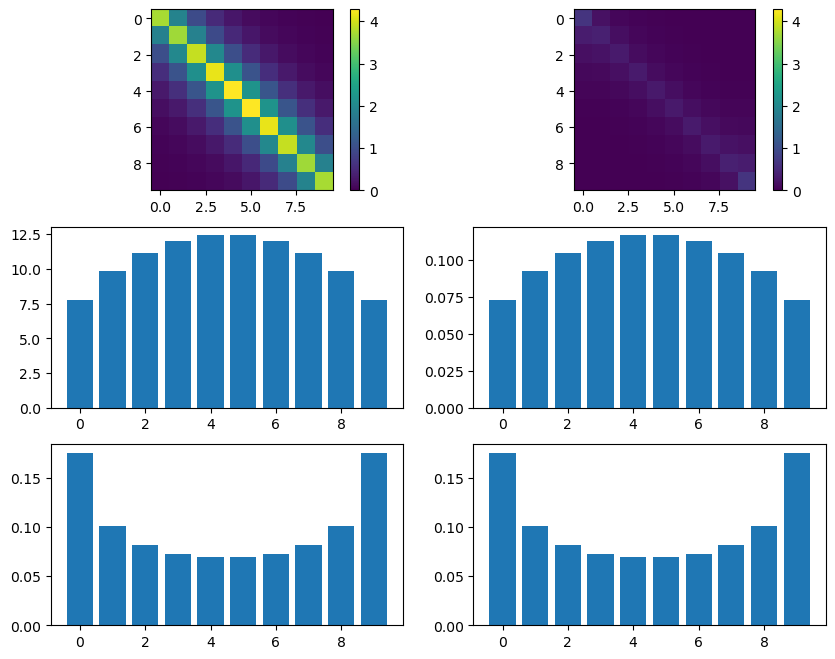

In [24]:
from scipy.stats import beta
import numpy as np
a = 0.44
b = 0.44
NC = 10

x = np.linspace(0+1/NC/2, 1-1/NC/2, NC)
y = beta.pdf(x, a, b)
y = y / np.sum(y)

CM = create_contact_matrix_ABC(NC, 6, y)

print(CM)


print("_____________")

CM2 = CM * y

print(CM2)

print("_____________")
print(np.sum(CM, axis=0))

print("_____________")

print(np.sum(CM2, axis=0))





fig, axs = plt.subplots(3,2, figsize=(10,8))

im = axs[0,0].imshow(CM, cmap='viridis', vmin =0, vmax=max([CM.max(), CM2.max()]))
fig.colorbar(im, ax=axs[0,0])

im2 = axs[0,1].imshow(CM2, cmap='viridis', vmin =0, vmax=max([CM.max(), CM2.max()]))
fig.colorbar(im2, ax=axs[0,1])

act_per_pop = np.sum(CM, axis=0)
act_per_pop2 = np.sum(CM, axis=0)

act_per_pop2_norm = act_per_pop2 / np.sum(act_per_pop2)

axs[1,0].bar(np.arange(len(y)), act_per_pop)
axs[1,1].bar(np.arange(len(y)), act_per_pop2_norm)

axs[2,0].bar(np.arange(len(y)), y)
axs[2,1].bar(np.arange(len(y)), y)

### SIR-V ###


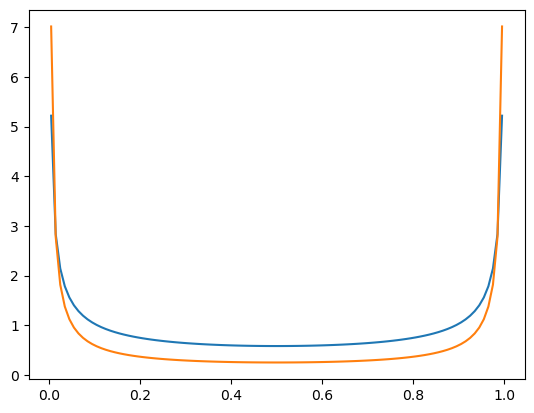

In [69]:
# plot a beta distribution with a = b = 0.44, and a beta with a = b = 0.15

from scipy.stats import beta
import numpy as np

print("### SIR-V ###")
x = np.linspace(0+1/100/2, 1-1/100/2, 100)
a = 0.44
b = 0.44
y = beta.pdf(x, a, b)
y = y / np.sum(y)
plt.plot(x, beta.pdf(x, a, b), label=f'Beta(a={a}, b={b})')

a = 0.15
b = 0.15
y = beta.pdf(x, a, b)
y = y / np.nansum(y)

plt.plot(x, beta.pdf(x, a, b), label=f'Beta(a={a}, b={b})')

### SIR-T ###
Completed beta_M = 0.15
Completed beta_M = 0.16041666666666665
Completed beta_M = 0.17083333333333334
Completed beta_M = 0.18125
Completed beta_M = 0.19166666666666665
Completed beta_M = 0.20208333333333334
Completed beta_M = 0.2125
Completed beta_M = 0.22291666666666665
Completed beta_M = 0.23333333333333334
Completed beta_M = 0.24375
Completed beta_M = 0.25416666666666665
Completed beta_M = 0.26458333333333334
Completed beta_M = 0.275
Completed beta_M = 0.28541666666666665
Completed beta_M = 0.2958333333333333
Completed beta_M = 0.30625
Completed beta_M = 0.31666666666666665
Completed beta_M = 0.3270833333333333
Completed beta_M = 0.3375
Completed beta_M = 0.34791666666666665
Completed beta_M = 0.3583333333333333
Completed beta_M = 0.36875
Completed beta_M = 0.37916666666666665
Completed beta_M = 0.3895833333333333
Completed beta_M = 0.4
### SIR-V ###
Completed beta_M = 0.15
Completed beta_M = 0.16041666666666665
Completed beta_M = 0.17083333333333334
Completed beta_M =

(array([49], dtype=int64), array([26], dtype=int64))


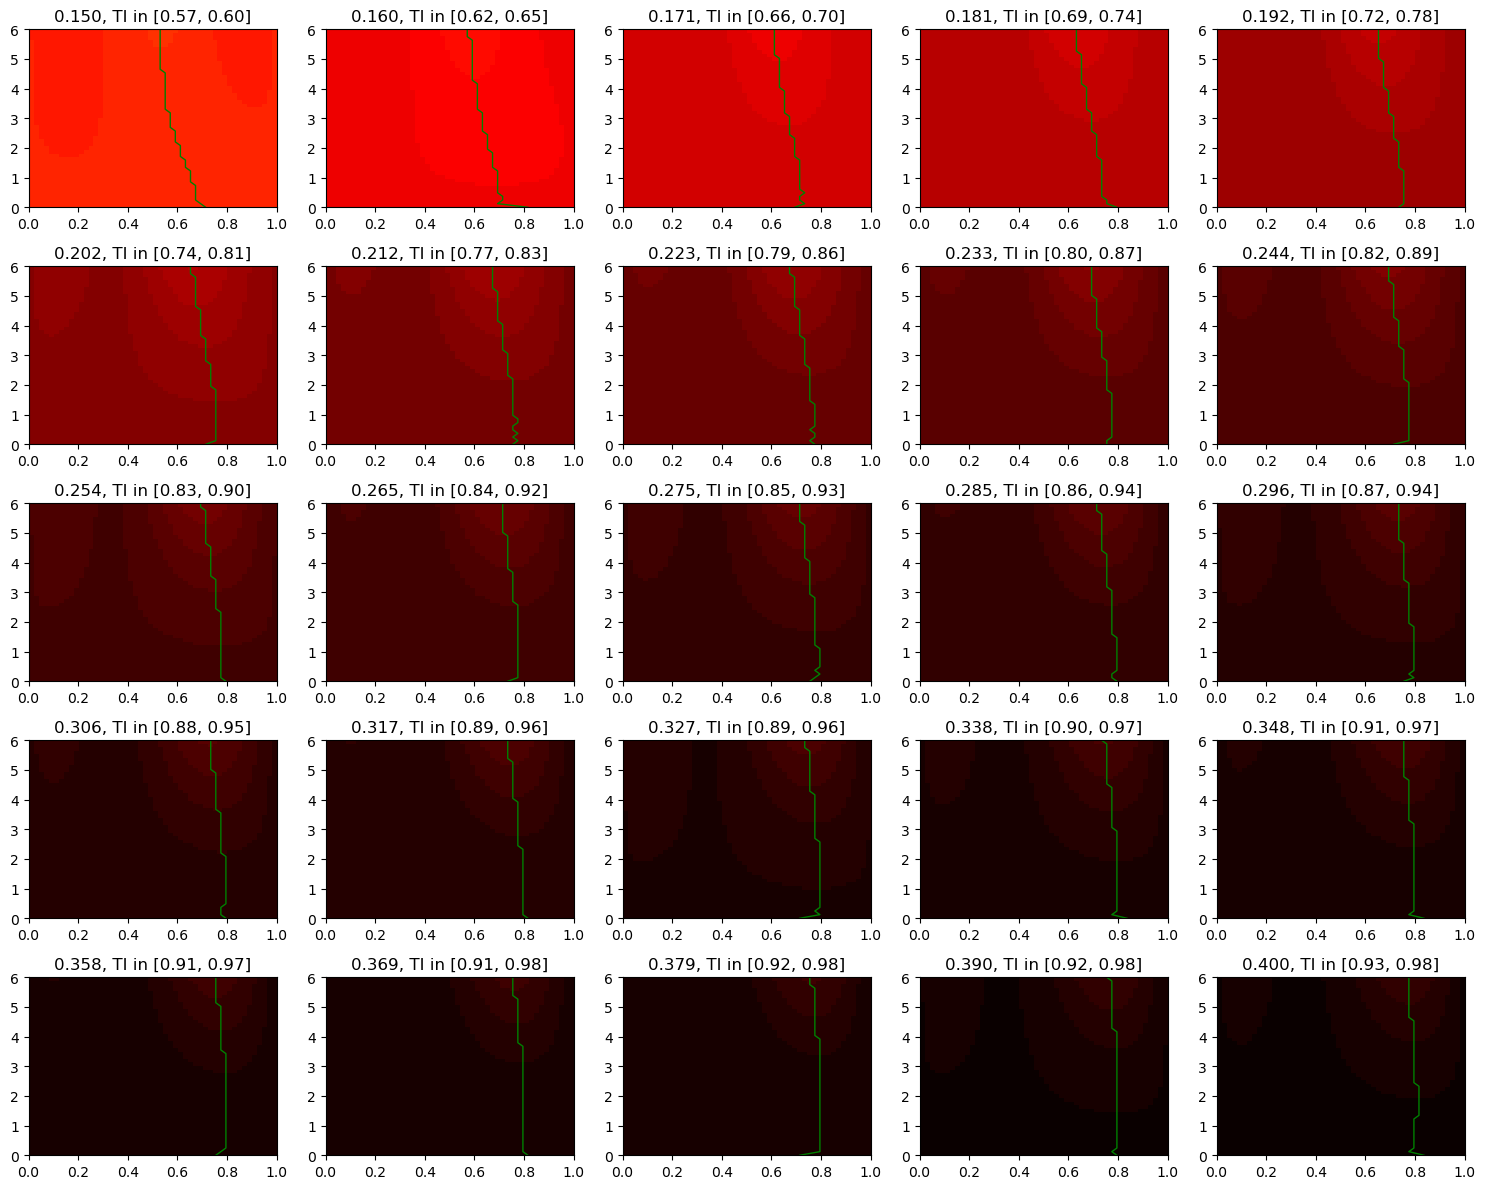

In [48]:
plot_25(res_list_T)

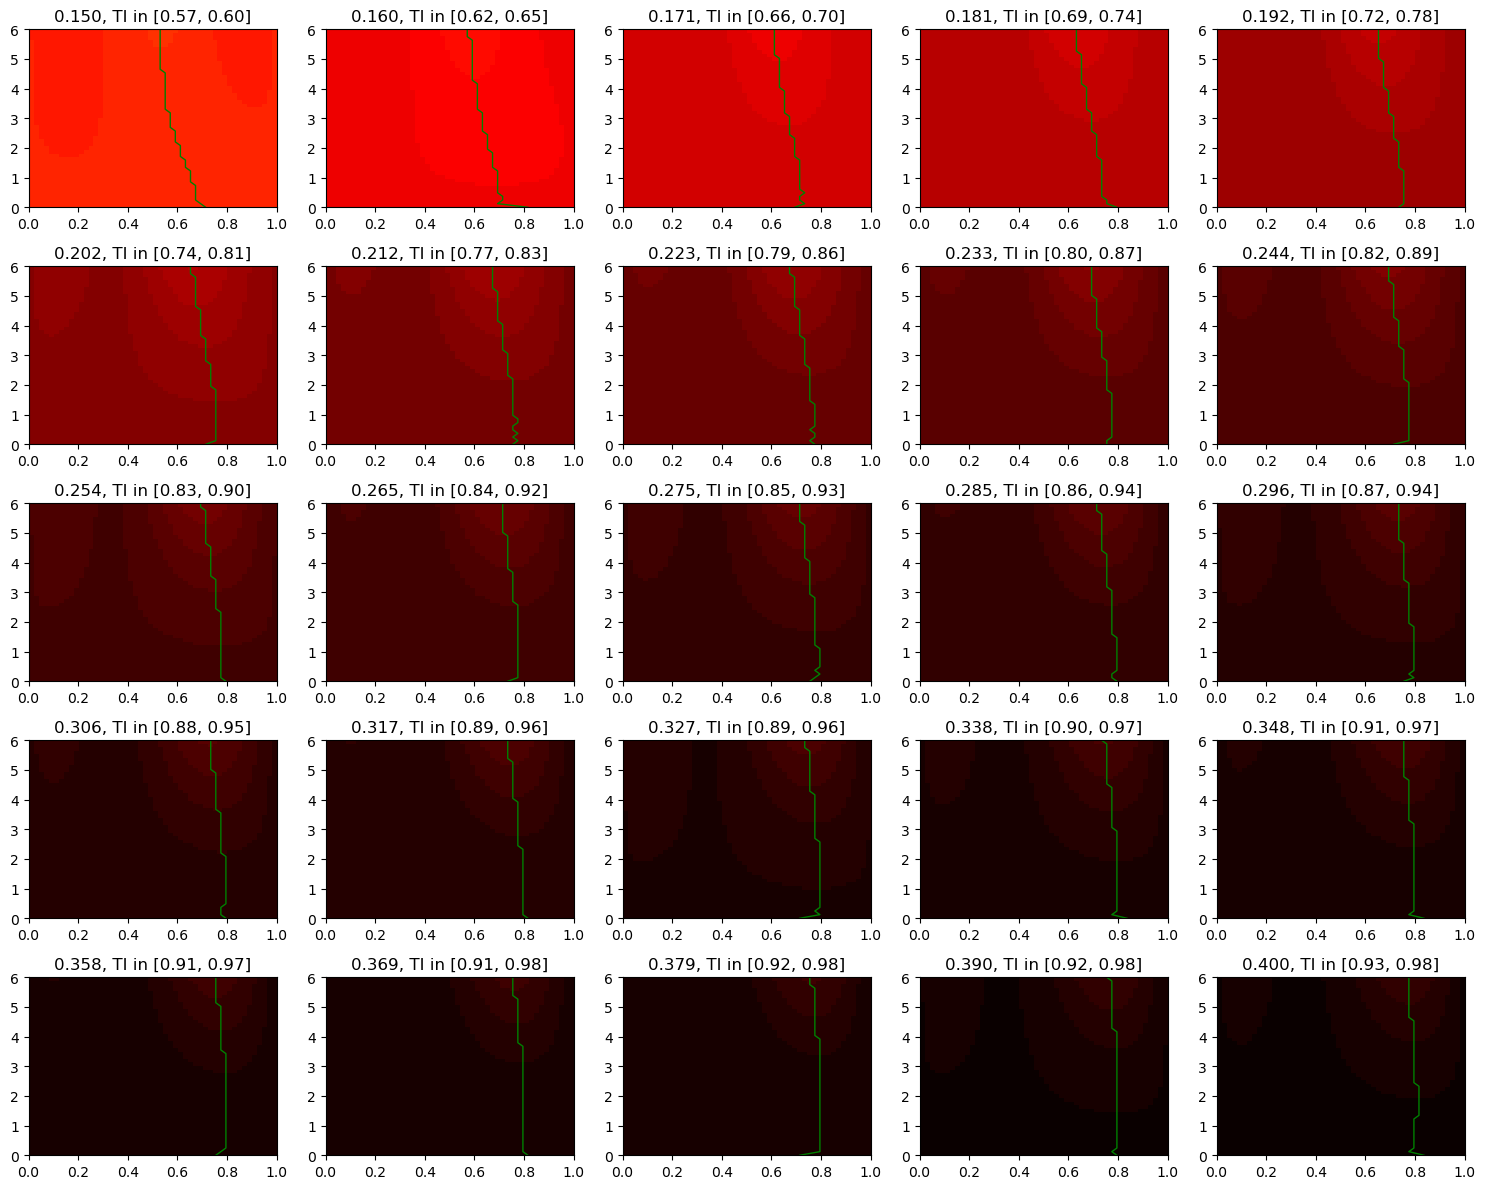

In [49]:
plot_25(res_list_V)

# PS = 20

In [42]:
NB = 50
NP = 50

homophilic_tendency = {"m": 0, "M": 20, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}
PARAMS["fixed_mean"] = 0.5
PARAMS["beta_M"] = 0.15


PS = 50


M_L = sweep_two_parameters(
    model_module=SIRM,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=2000
)

PARAMS["beta_M"] = 0.2
M_M = sweep_two_parameters(
    model_module=SIRM,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=2000
)


PARAMS["beta_M"] = 0.4
M_H = sweep_two_parameters(
    model_module=SIRM,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=2000
)


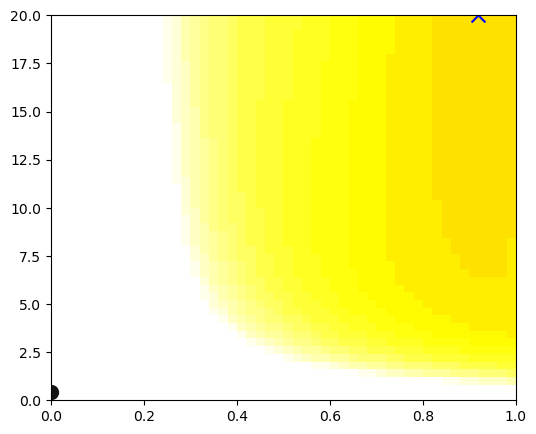

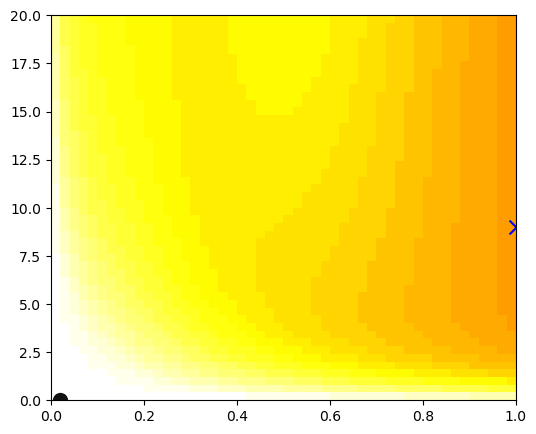

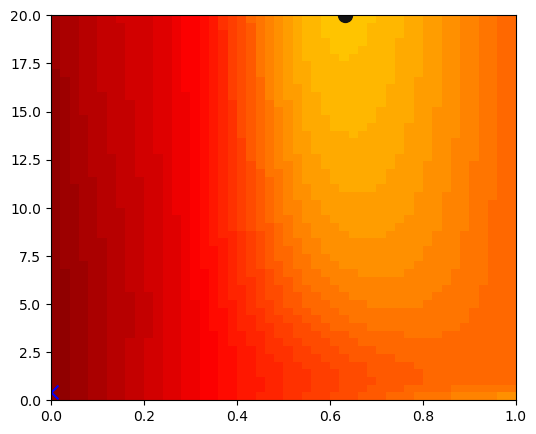

In [43]:
fig, ax = plt.subplots(1,1, figsize=(6,5))

TI = np.sum(M_L["final_state"]["I"] + M_L["final_state"]["R"], axis=2)

ax.imshow(
    TI, vmin = 0, vmax = 1, cmap = my_map,
    origin='lower', extent=[0, 1, 0, 20],
    aspect='auto')
# find maximum infection point    # print coordinates of maximum infection point
max_idx = np.unravel_index(np.nanargmax(TI, axis=None), TI.shape)
max_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (max_idx[1] / (pol_range["n"] - 1))
max_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (max_idx[0] / (homophilic_tendency["n"] - 1))
ax.scatter(max_pol, max_homophily, color='blue', marker='x', s=100)

# find minimum infection point
min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))
ax.scatter(min_pol, min_homophily, marker='o', s=100, color ="#121212")


fig, ax = plt.subplots(1,1, figsize=(6,5))

TI = np.sum(M_M["final_state"]["I"] + M_M["final_state"]["R"], axis=2)

ax.imshow(
    TI, vmin = 0, vmax = 1, cmap = my_map,
    origin='lower', extent=[0, 1, 0, 20],
    aspect='auto')
# find maximum infection point    # print coordinates of maximum infection point
max_idx = np.unravel_index(np.nanargmax(TI, axis=None), TI.shape)
max_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (max_idx[1] / (pol_range["n"] - 1))
max_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (max_idx[0] / (homophilic_tendency["n"] - 1))
ax.scatter(max_pol, max_homophily, color='blue', marker='x', s=100)

# find minimum infection point
min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))
ax.scatter(min_pol, min_homophily, marker='o', s=100, color ="#121212")


fig, ax = plt.subplots(1,1, figsize=(6,5))

TI = np.sum(M_H["final_state"]["I"] + M_H["final_state"]["R"], axis=2)

ax.imshow(
    TI, vmin = 0, vmax = 1, cmap = my_map,
    origin='lower', extent=[0, 1, 0, 20],
    aspect='auto')
# find maximum infection point    # print coordinates of maximum infection point
max_idx = np.unravel_index(np.nanargmax(TI, axis=None), TI.shape)
max_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (max_idx[1] / (pol_range["n"] - 1))
max_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (max_idx[0] / (homophilic_tendency["n"] - 1))
ax.scatter(max_pol, max_homophily, color='blue', marker='x', s=100)

# find minimum infection point
min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))
ax.scatter(min_pol, min_homophily, marker='o', s=100, color ="#121212")


# Explore the range 0.2-0.3

In [44]:
betas = np.linspace(0.2, 0.3, 9)

res_list = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list.append(M)
    print(f"Completed beta_M = {b}")

Completed beta_M = 0.2
Completed beta_M = 0.21250000000000002
Completed beta_M = 0.225
Completed beta_M = 0.2375
Completed beta_M = 0.25
Completed beta_M = 0.2625
Completed beta_M = 0.275
Completed beta_M = 0.2875
Completed beta_M = 0.3


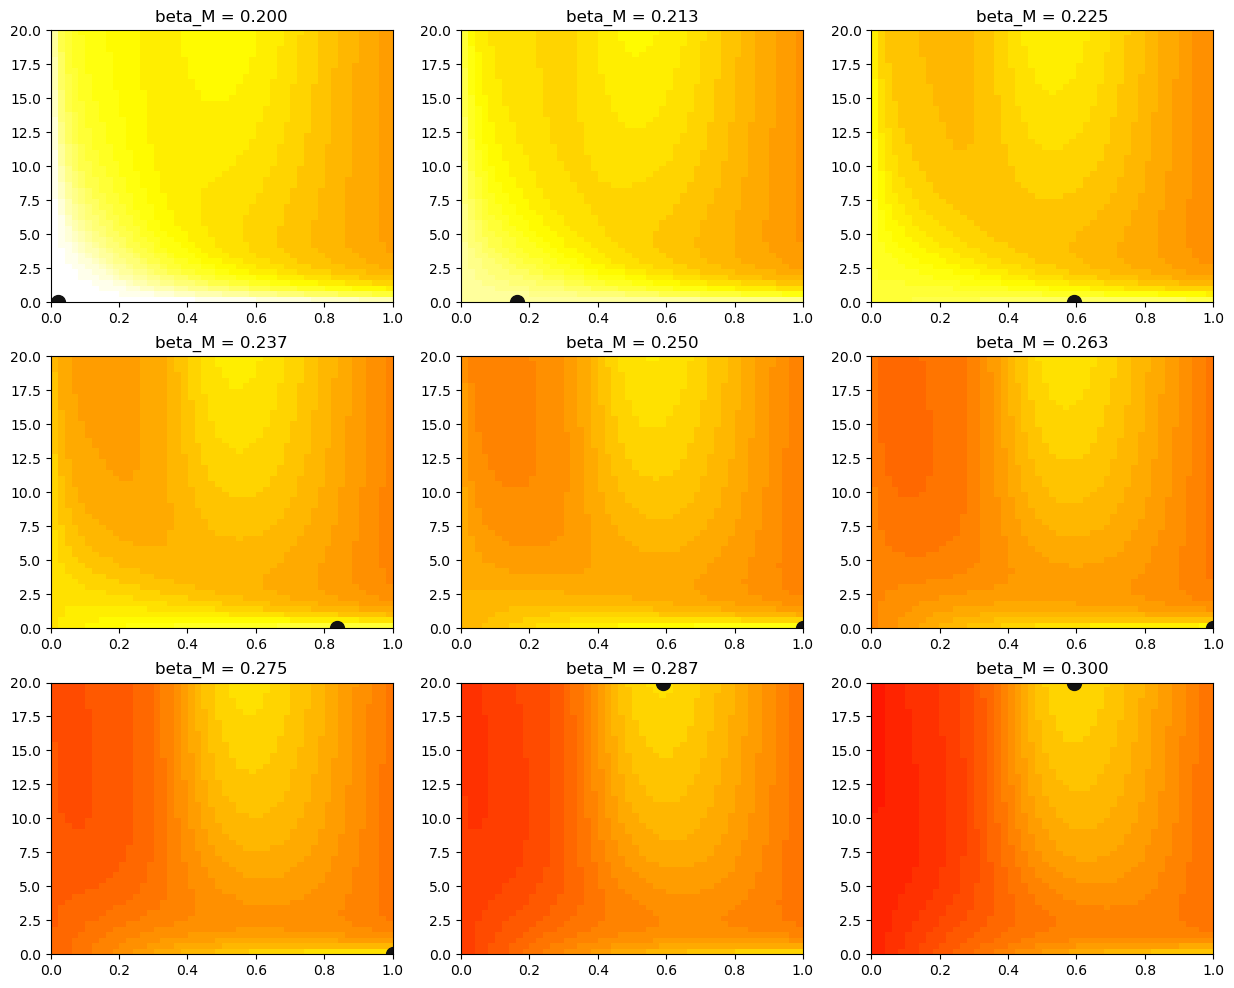

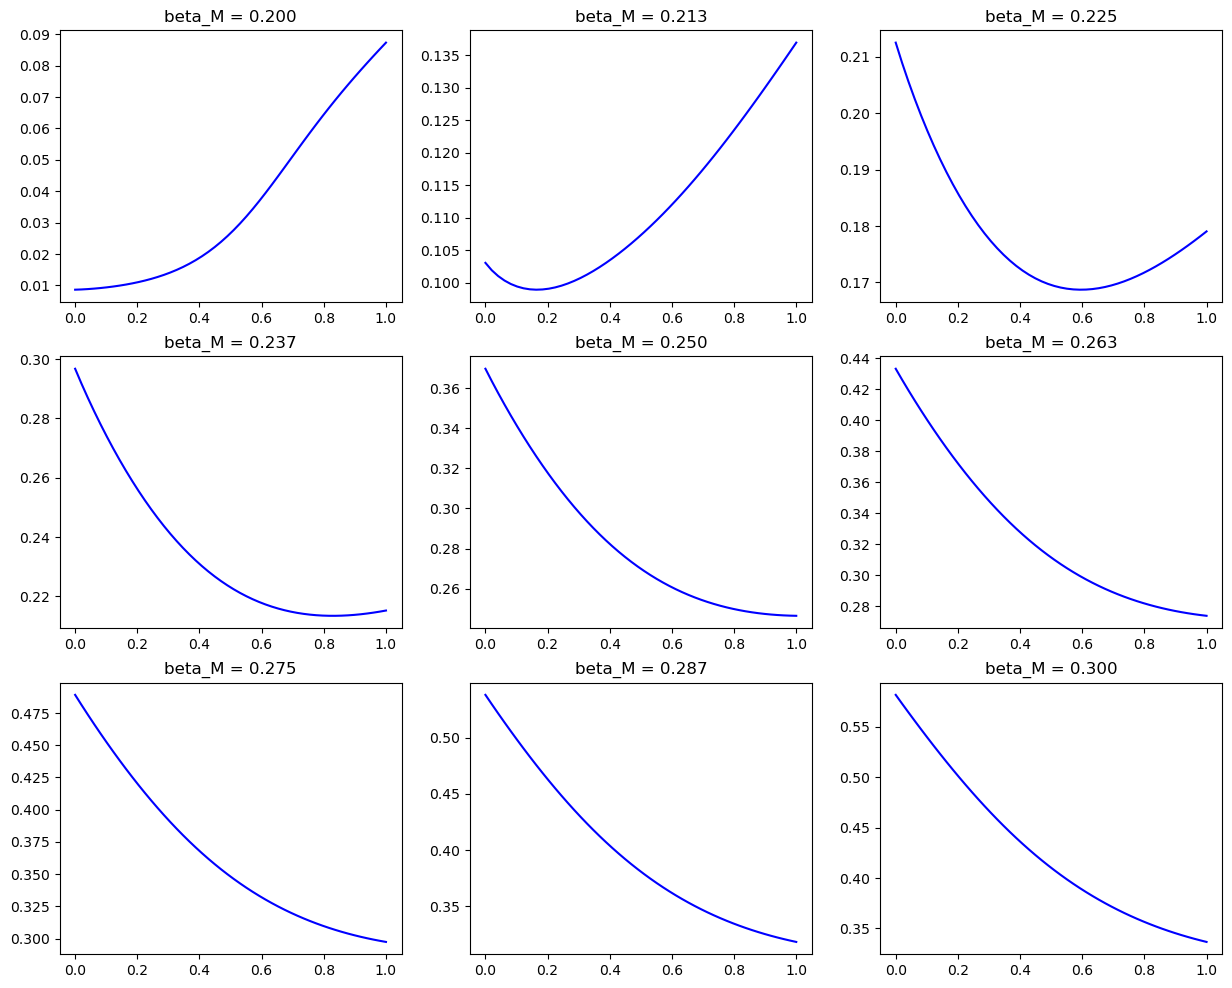

In [45]:
# plot all of them in one figure
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, ax in enumerate(axes.flatten()):
    TI = np.sum(res_list[i]["final_state"]["I"] + res_list[i]["final_state"]["R"], axis=2)

    im = ax.imshow(
        TI, vmin = 0, vmax = 1, cmap = my_map,
        origin='lower', extent=[0, 1, 0, 20],
        aspect='auto')
    ax.set_title(f"beta_M = {betas[i]:.3f}")
    # print a x where the minimum is
    min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
    min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
    min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))
    ax.scatter(min_pol, min_homophily, marker='o', s=100, color ="#121212")


# simply plot the TI(pol| hom = 0)

fig, ax = plt.subplots(3,3, figsize=(15,12))
for i in range(9):
    TI = np.sum(res_list[i]["final_state"]["I"] + res_list[i]["final_state"]["R"], axis=2)
    TI_h0 = TI[0,:]  # homophily = 0 corresponds to the first row
    ax.flatten()[i].plot(
        np.linspace(0, 1, NP),
        TI_h0,
        color='blue'
    )
    ax.flatten()[i].set_title(f"beta_M = {betas[i]:.3f}")

### the Jensen inequality tells me that this should be strictly decreasing with beta_M. WHY ISN'T IT?
### Hypothesis: we are not at h = 0, but at a small value of it: min(h) = 20/50/2 = 0.2 let's try again with a smaller range of homophily

In [46]:
betas = np.linspace(0.2, 0.3, 9)
homophilic_tendency = {"m": 0, "M": 0.1, "n": NB}
res_list_fine = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_fine.append(M)
    print(f"Completed beta_M = {b}")

Completed beta_M = 0.2
Completed beta_M = 0.21250000000000002
Completed beta_M = 0.225
Completed beta_M = 0.2375
Completed beta_M = 0.25
Completed beta_M = 0.2625
Completed beta_M = 0.275
Completed beta_M = 0.2875
Completed beta_M = 0.3


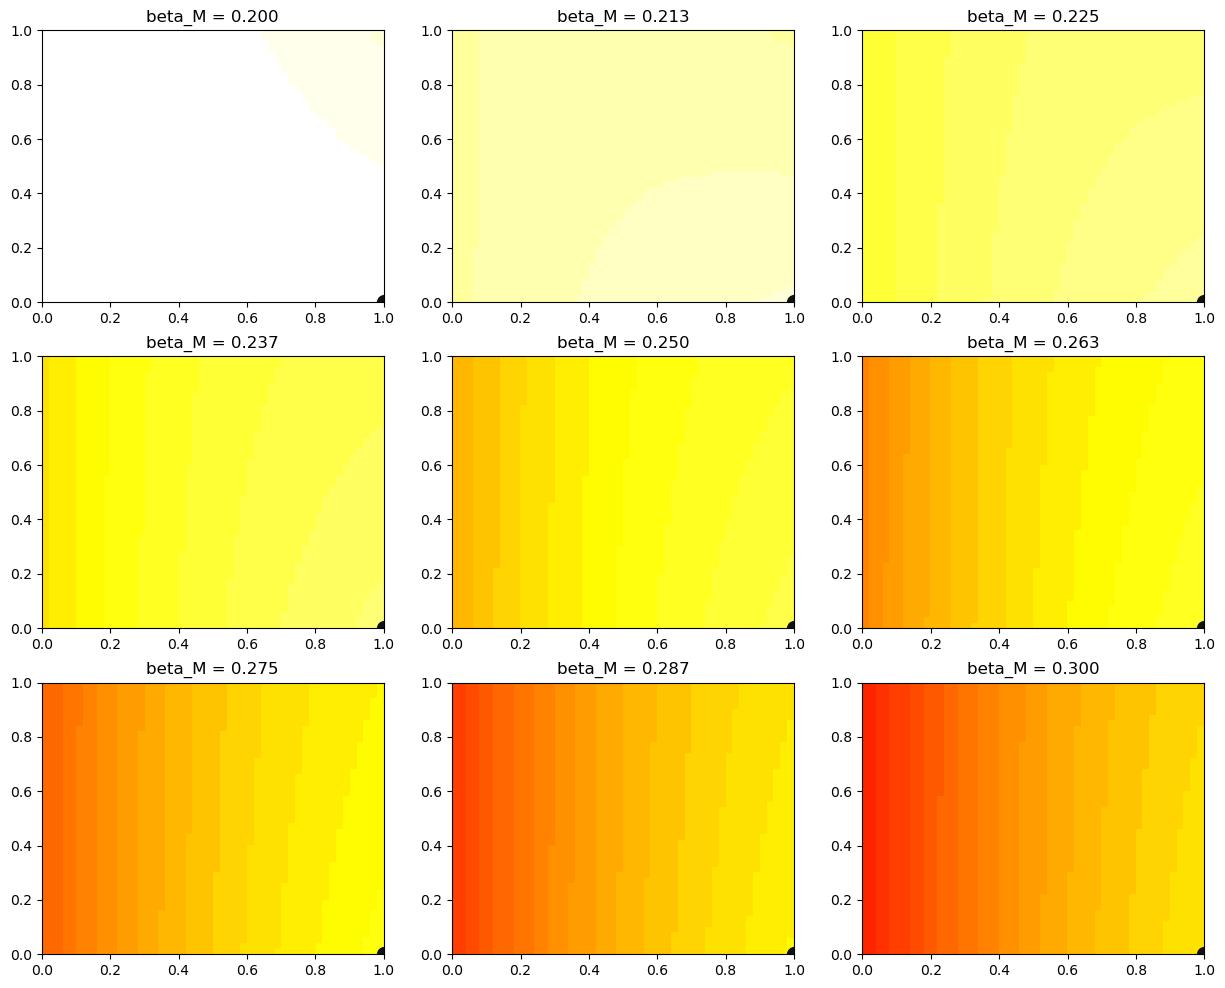

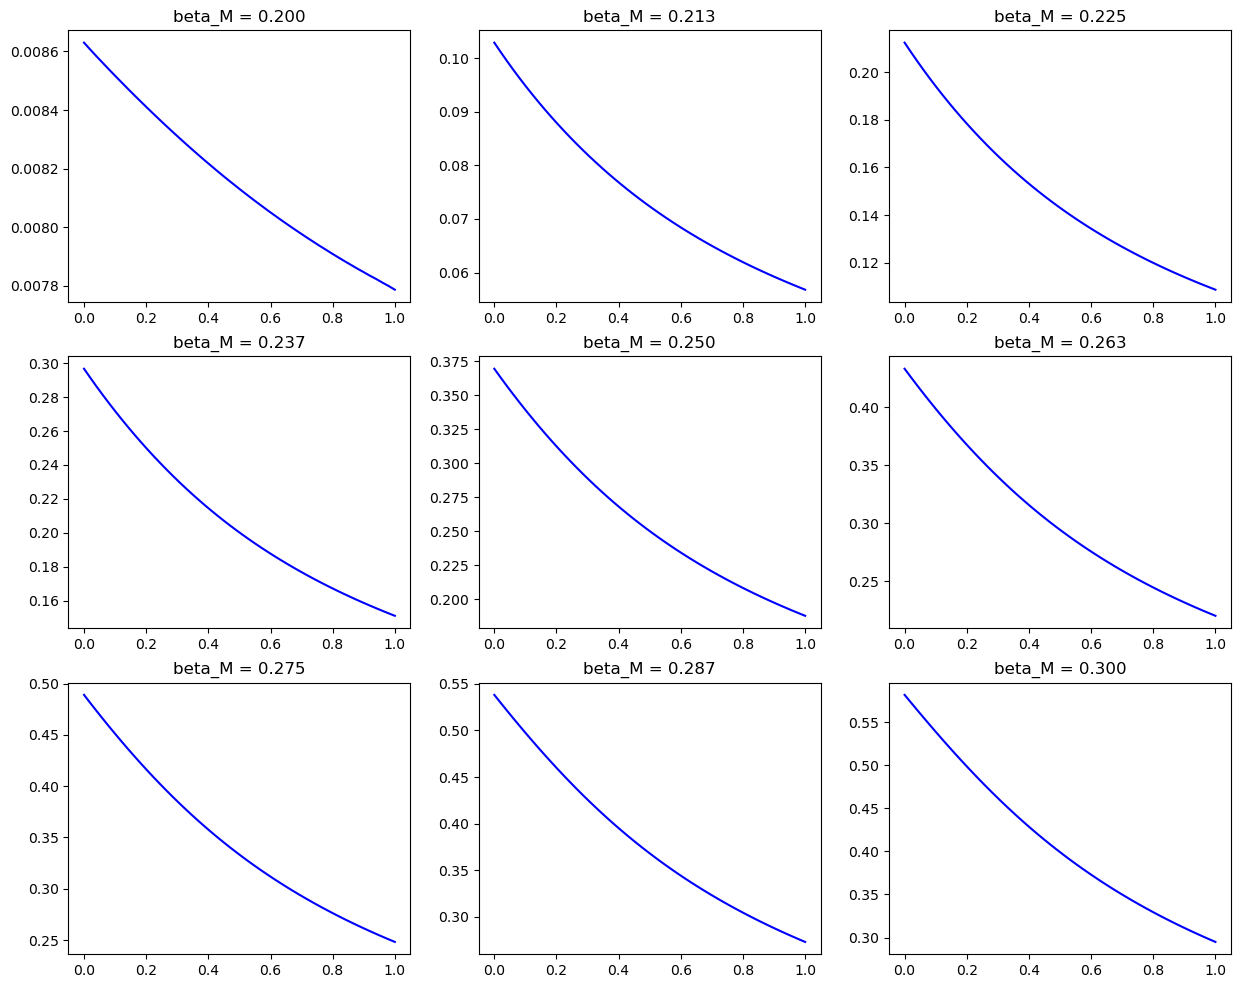

In [47]:
# plot all of them in one figure
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, ax in enumerate(axes.flatten()):
    TI = np.sum(res_list_fine[i]["final_state"]["I"] + res_list_fine[i]["final_state"]["R"], axis=2)

    im = ax.imshow(
        TI, vmin = 0, vmax = 1, cmap = my_map,
        origin='lower', extent=[0, 1, 0, 1],
        aspect='auto')
    ax.set_title(f"beta_M = {betas[i]:.3f}")
    # print a x where the minimum is
    min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
    min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
    min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))
    ax.scatter(min_pol, min_homophily, marker='o', s=100, color ="#121212")


# simply plot the TI(pol| hom = 0)

fig, ax = plt.subplots(3,3, figsize=(15,12))
for i in range(9):
    TI = np.sum(res_list_fine[i]["final_state"]["I"] + res_list_fine[i]["final_state"]["R"], axis=2)
    TI_h0 = TI[0,:]  # homophily = 0 corresponds to the first row
    ax.flatten()[i].plot(
        np.linspace(0, 1, NP),
        TI_h0,
        color='blue'
    )
    ax.flatten()[i].set_title(f"beta_M = {betas[i]:.3f}")

### The value of h where the Jensen inequality stop working increases with beta_M. 
The higher beta_M is the the higher h can be, and the Jensen inequality also

Completed beta_M = 0.15
Completed beta_M = 0.16041666666666665
Completed beta_M = 0.17083333333333334
Completed beta_M = 0.18125
Completed beta_M = 0.19166666666666665
Completed beta_M = 0.20208333333333334
Completed beta_M = 0.2125
Completed beta_M = 0.22291666666666665
Completed beta_M = 0.23333333333333334
Completed beta_M = 0.24375
Completed beta_M = 0.25416666666666665
Completed beta_M = 0.26458333333333334
Completed beta_M = 0.275
Completed beta_M = 0.28541666666666665
Completed beta_M = 0.2958333333333333
Completed beta_M = 0.30625
Completed beta_M = 0.31666666666666665
Completed beta_M = 0.3270833333333333
Completed beta_M = 0.3375
Completed beta_M = 0.34791666666666665
Completed beta_M = 0.3583333333333333
Completed beta_M = 0.36875
Completed beta_M = 0.37916666666666665
Completed beta_M = 0.3895833333333333
Completed beta_M = 0.4


Completed beta_M = 0.15
Completed beta_M = 0.16041666666666665
Completed beta_M = 0.17083333333333334
Completed beta_M = 0.18125
Completed beta_M = 0.19166666666666665
Completed beta_M = 0.20208333333333334
Completed beta_M = 0.2125
Completed beta_M = 0.22291666666666665
Completed beta_M = 0.23333333333333334
Completed beta_M = 0.24375
Completed beta_M = 0.25416666666666665
Completed beta_M = 0.26458333333333334


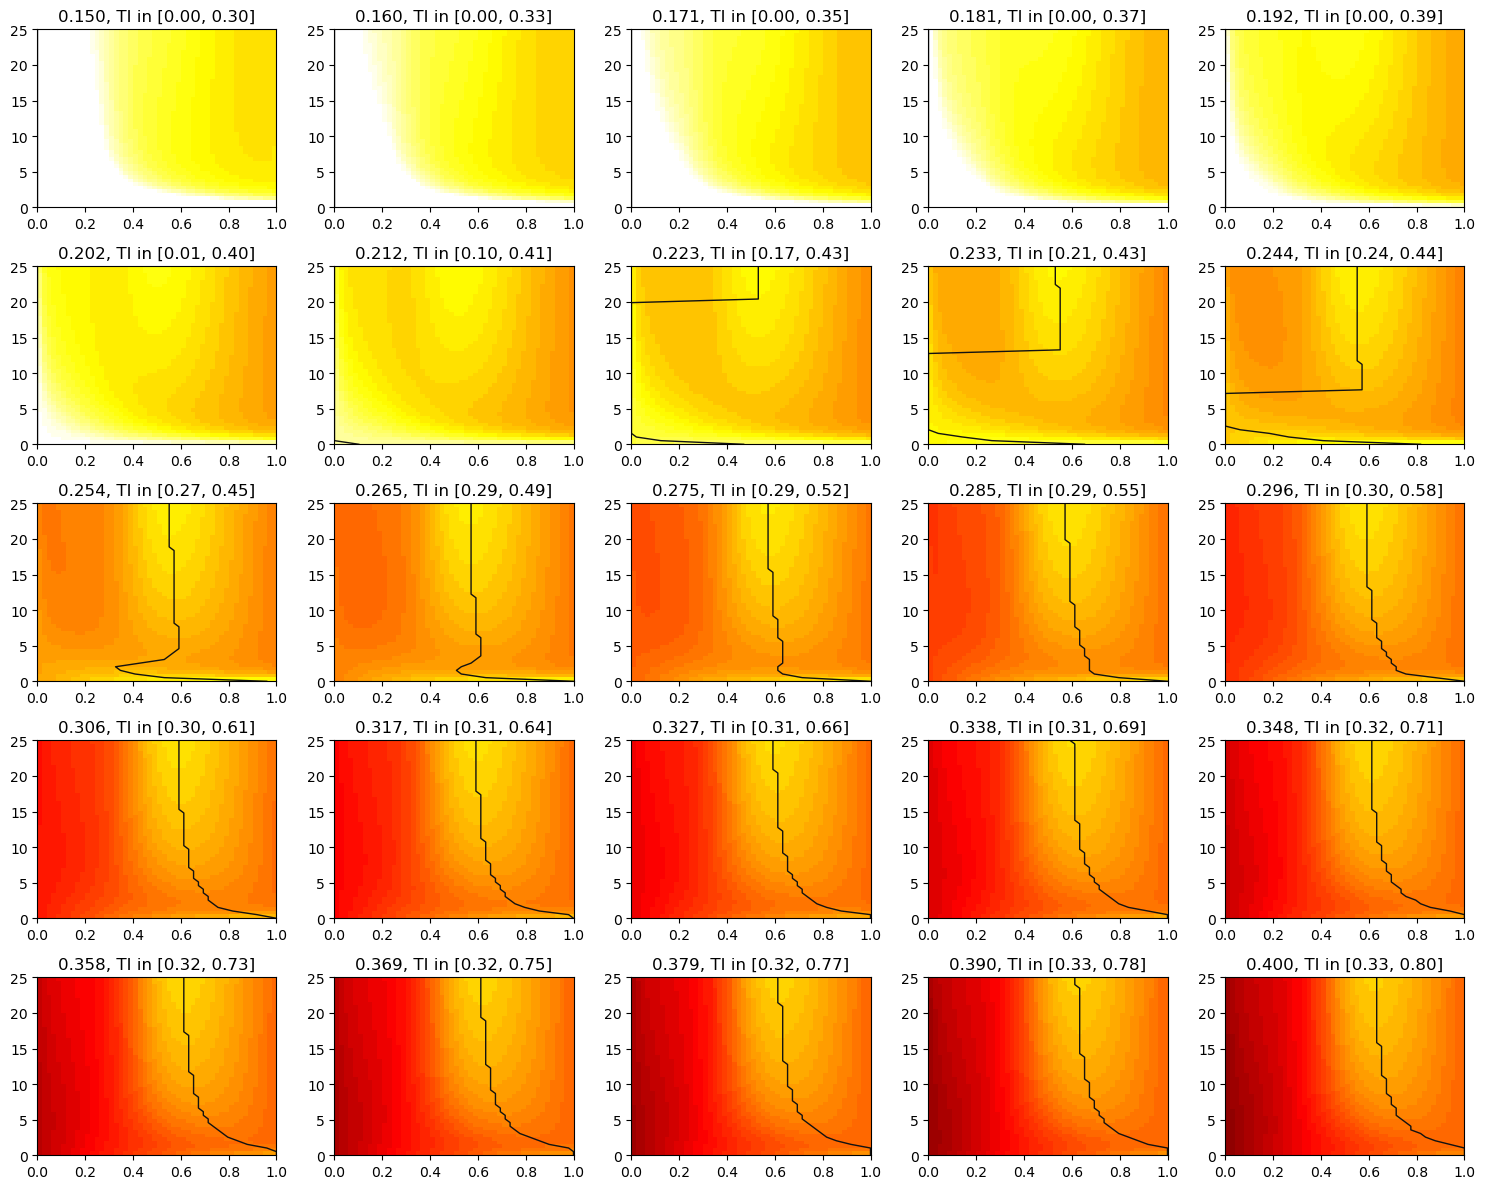

In [67]:
# plot all of them in one figure
fig, axes = plt.subplots(5, 5, figsize=(15, 12))

for i, ax in enumerate(axes.flatten()):
    TI = np.sum(res_list[i]["final_state"]["I"] + res_list[i]["final_state"]["R"], axis=2)

    im = ax.imshow(
        TI, vmin = 0, vmax = 1, cmap = my_map,
        origin='lower', extent=[0, 1, 0, 25],
        aspect='auto')
    ax.set_title(f"{betas[i]:.3f}, TI in [{TI.min():.2f}, {TI.max():.2f}]")
    
    # Find minimum polarization for each homophily level
    min_pol_curve = []
    homophily_values = []
    
    for h_idx in range(TI.shape[0]):  # iterate over homophily axis (rows)
        # Find minimum polarization index for this homophily level
        pol_idx = np.nanargmin(TI[h_idx, :])
        
        # Convert indices to actual values
        min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (pol_idx / (pol_range["n"] - 1))
        homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (h_idx / (homophilic_tendency["n"] - 1))
        
        min_pol_curve.append(min_pol)
        homophily_values.append(homophily)
    
    # Plot the curve
    ax.plot(min_pol_curve, homophily_values, color="#121212", linewidth=1)

fig.tight_layout()

In [68]:
betas = np.linspace(0.15, 0.4, 25)
NB = 50
NP = 50
homophilic_tendency = {"m": 0, "M": 25, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}
res_list_T = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRT,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_T.append(M)
    print(f"Completed beta_M = {b}")

Completed beta_M = 0.15
Completed beta_M = 0.16041666666666665
Completed beta_M = 0.17083333333333334
Completed beta_M = 0.18125
Completed beta_M = 0.19166666666666665
Completed beta_M = 0.20208333333333334
Completed beta_M = 0.2125
Completed beta_M = 0.22291666666666665
Completed beta_M = 0.23333333333333334
Completed beta_M = 0.24375
Completed beta_M = 0.25416666666666665
Completed beta_M = 0.26458333333333334
Completed beta_M = 0.275
Completed beta_M = 0.28541666666666665
Completed beta_M = 0.2958333333333333
Completed beta_M = 0.30625
Completed beta_M = 0.31666666666666665
Completed beta_M = 0.3270833333333333
Completed beta_M = 0.3375
Completed beta_M = 0.34791666666666665
Completed beta_M = 0.3583333333333333
Completed beta_M = 0.36875
Completed beta_M = 0.37916666666666665
Completed beta_M = 0.3895833333333333
Completed beta_M = 0.4


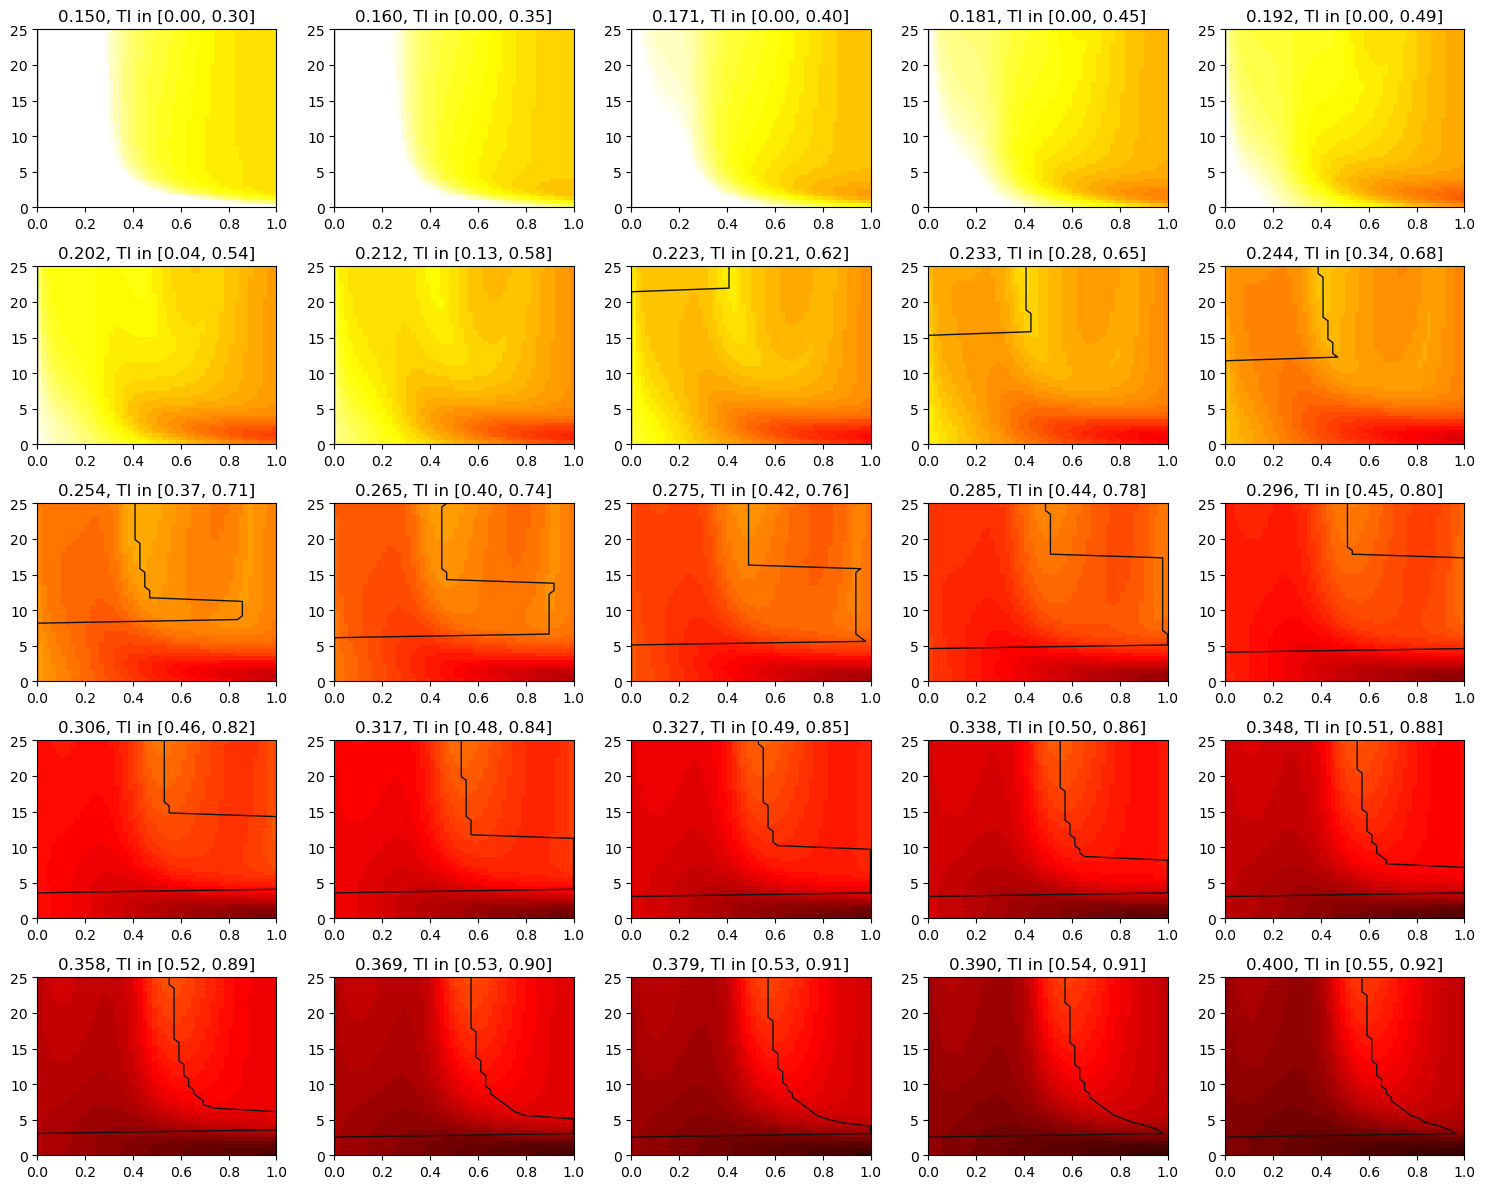

In [69]:
# plot all of them in one figure
fig, axes = plt.subplots(5, 5, figsize=(15, 12))

for i, ax in enumerate(axes.flatten()):
    TI = np.sum(res_list_T[i]["final_state"]["I"] + res_list_T[i]["final_state"]["R"], axis=2)

    im = ax.imshow(
        TI, vmin = 0, vmax = 1, cmap = my_map,
        origin='lower', extent=[0, 1, 0, 25],
        aspect='auto')
    ax.set_title(f"{betas[i]:.3f}, TI in [{TI.min():.2f}, {TI.max():.2f}]")
    
    # Find minimum polarization for each homophily level
    min_pol_curve = []
    homophily_values = []
    
    for h_idx in range(TI.shape[0]):  # iterate over homophily axis (rows)
        # Find minimum polarization index for this homophily level
        pol_idx = np.nanargmin(TI[h_idx, :])
        
        # Convert indices to actual values
        min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (pol_idx / (pol_range["n"] - 1))
        homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (h_idx / (homophilic_tendency["n"] - 1))
        
        min_pol_curve.append(min_pol)
        homophily_values.append(homophily)
    
    # Plot the curve
    ax.plot(min_pol_curve, homophily_values, color="#121212", linewidth=1)

fig.tight_layout()

In [70]:
betas = np.linspace(0.15, 0.4, 25)
NB = 50
NP = 50
homophilic_tendency = {"m": 0, "M": 25, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}
res_list_V = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRV,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_V.append(M)
    print(f"Completed beta_M = {b}")

Completed beta_M = 0.15
Completed beta_M = 0.16041666666666665
Completed beta_M = 0.17083333333333334
Completed beta_M = 0.18125
Completed beta_M = 0.19166666666666665
Completed beta_M = 0.20208333333333334
Completed beta_M = 0.2125
Completed beta_M = 0.22291666666666665
Completed beta_M = 0.23333333333333334
Completed beta_M = 0.24375
Completed beta_M = 0.25416666666666665
Completed beta_M = 0.26458333333333334
Completed beta_M = 0.275
Completed beta_M = 0.28541666666666665
Completed beta_M = 0.2958333333333333
Completed beta_M = 0.30625
Completed beta_M = 0.31666666666666665
Completed beta_M = 0.3270833333333333
Completed beta_M = 0.3375
Completed beta_M = 0.34791666666666665
Completed beta_M = 0.3583333333333333
Completed beta_M = 0.36875
Completed beta_M = 0.37916666666666665
Completed beta_M = 0.3895833333333333
Completed beta_M = 0.4


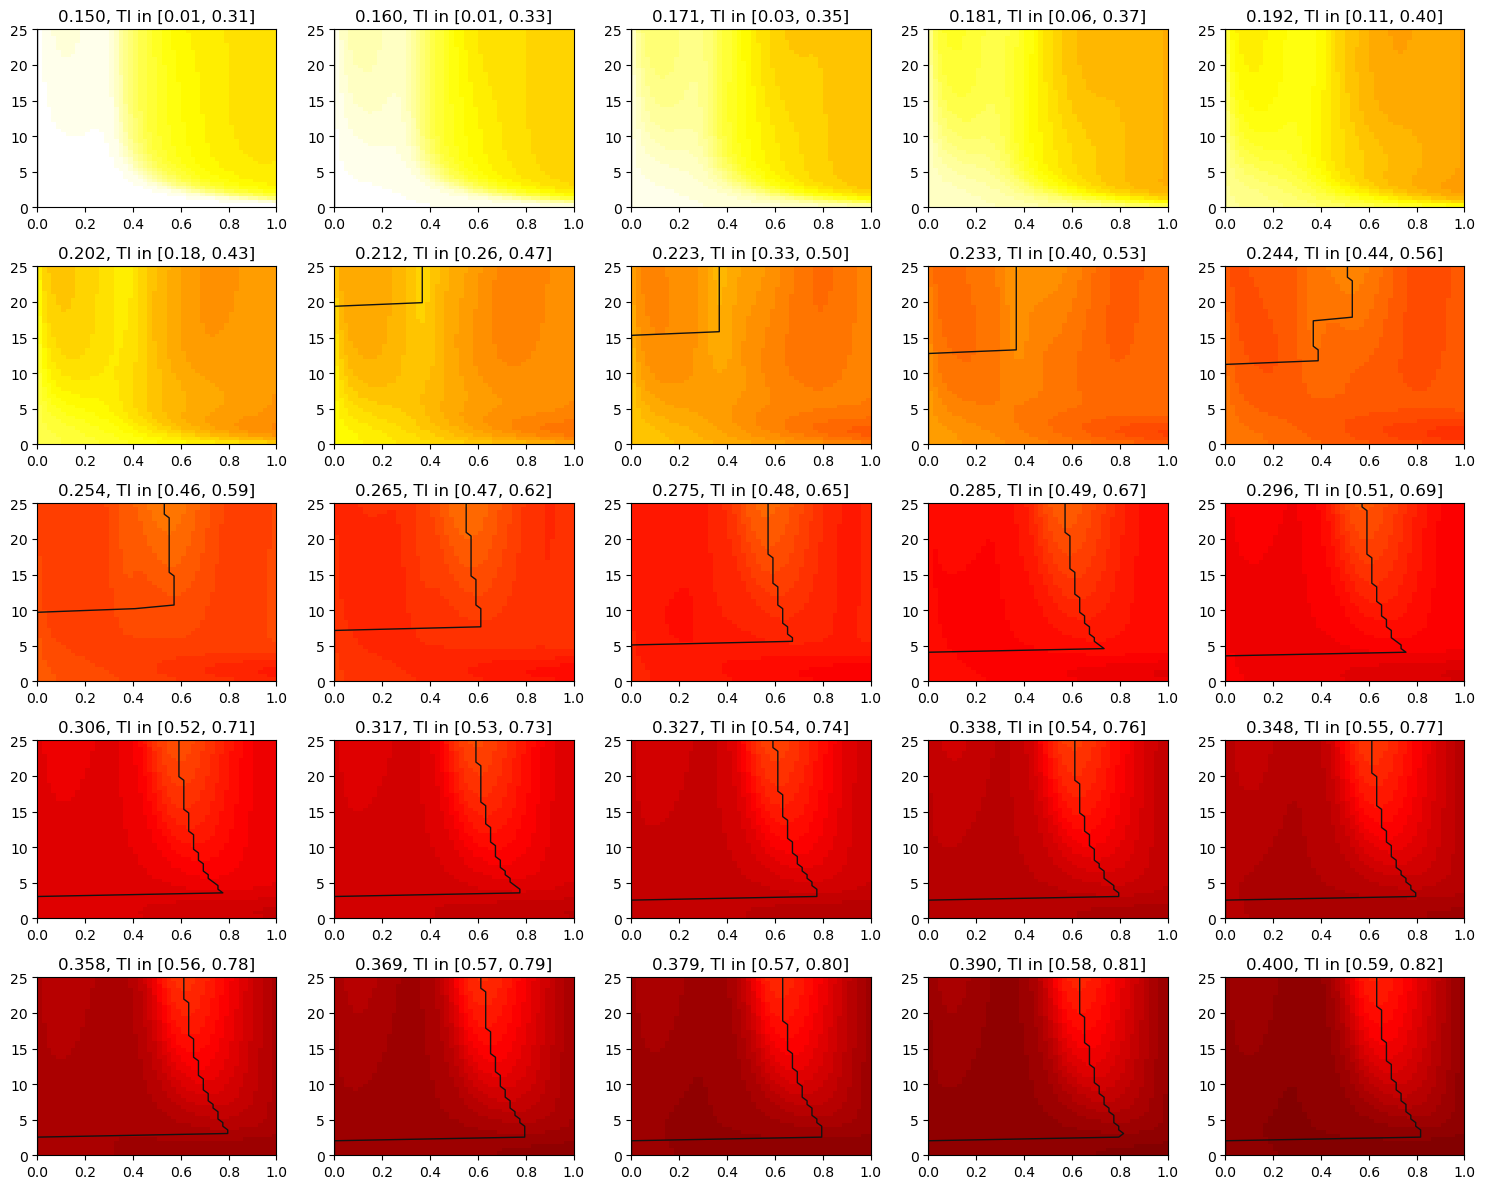

In [71]:
# plot all of them in one figure
fig, axes = plt.subplots(5, 5, figsize=(15, 12))

for i, ax in enumerate(axes.flatten()):
    TI = np.sum(res_list_V[i]["final_state"]["I"] + res_list_V[i]["final_state"]["R"], axis=2)

    im = ax.imshow(
        TI, vmin = 0, vmax = 1, cmap = my_map,
        origin='lower', extent=[0, 1, 0, 25],
        aspect='auto')
    ax.set_title(f"{betas[i]:.3f}, TI in [{TI.min():.2f}, {TI.max():.2f}]")
    
    # Find minimum polarization for each homophily level
    min_pol_curve = []
    homophily_values = []
    
    for h_idx in range(TI.shape[0]):  # iterate over homophily axis (rows)
        # Find minimum polarization index for this homophily level
        pol_idx = np.nanargmin(TI[h_idx, :])
        
        # Convert indices to actual values
        min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (pol_idx / (pol_range["n"] - 1))
        homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (h_idx / (homophilic_tendency["n"] - 1))
        
        min_pol_curve.append(min_pol)
        homophily_values.append(homophily)
    
    # Plot the curve
    ax.plot(min_pol_curve, homophily_values, color="#121212", linewidth=1)

fig.tight_layout()

In [56]:
"""
Final Size Equation Solver for SIRM Model
Standalone version - directly implements needed functions
Based on Andreasen (2011) equation (13): Ax = h(x) where h(x) = -log(1-x)
"""

import jax
import jax.numpy as jnp
import numpy as np
from scipy.optimize import fsolve


# ===== Functions from distributions.py =====
def pol_mean_to_ab(pol: float, m: float = 0.5):
    """Convert polarization and mean to alpha, beta parameters of beta distribution"""
    a = -m*(4*(m-1)*m+pol)/pol
    b = 4*m*(m-1)**2/pol +m - 1
    return a, b


def my_beta_asymmetric(a: float, b: float, n_groups: int, norm: float = 1.0):
    """Generate population sizes based on asymmetric beta distribution"""
    from jax.scipy.stats import beta as jbeta
    
    bin_edges = jnp.linspace(0, 1, n_groups + 1)
    bin_probs = jnp.array([jbeta.cdf(bin_edges[i+1], a, b) - jbeta.cdf(bin_edges[i], a, b) 
                           for i in range(n_groups)])
    
    return bin_probs / jnp.sum(bin_probs) * norm


# ===== Functions from Contact_Matrix.py =====
def create_contact_matrix(n_groups, homophilic_tendency, group_sizes):
    """Create contact matrix with exponential decay based on distance"""
    positions = jnp.linspace(0, 1, n_groups)
    diffs = jnp.abs(positions[:, None] - positions[None, :])
    weights = jnp.exp(-homophilic_tendency * diffs)
    C = weights * n_groups * n_groups
    
    # Normalize
    C = C / jnp.sum(C, axis=1, keepdims=True)
    TC = jnp.sum(jnp.outer(group_sizes, group_sizes) * C)
    C = C / TC
    
    return C


# ===== Functions from model_utils.py =====
def generate_behavior_pattern(population_size: int, params: dict, max_val: float, min_val: float = 0.0):
    """Generate behavior pattern across population compartments"""
    x = jnp.linspace(0, 1, num=population_size)
    return min_val + (max_val - min_val) * jnp.power(x, params.get('SPB_exponent', 1.0))


# ===== SIRM R0 calculation =====
def power_iteration(matrix: jnp.ndarray, num_iterations: int = 100) -> float:
    """Calculate largest eigenvalue using power iteration method"""
    n = matrix.shape[0]
    vector = jnp.ones(n)
    
    def body_fun(_, v):
        v_new = matrix @ v
        return v_new / jnp.linalg.norm(v_new)
    
    vector = jax.lax.fori_loop(0, num_iterations, body_fun, vector)
    return jnp.vdot(matrix @ vector, vector) / jnp.vdot(vector, vector)


def create_ngm_SIRM(gamma, susceptibility, populations, C):
    """Create next generation matrix from model parameters"""
    pop_fractions = populations / jnp.sum(populations)
    return (1/gamma) * jnp.diag(susceptibility * pop_fractions) @ C


# ===== Simplified SIRM simulation =====
@jax.jit
def sirm_step(state, susceptibilities, gamma, contact_matrix, dT):
    """Execute one time step of the SIRM model"""
    S, I, R = state
    
    # Force of infection
    infection_force = contact_matrix @ I
    
    new_infections = susceptibilities * S * infection_force * dT
    new_recoveries = gamma * I * dT

    S_new = S - new_infections
    I_new = I + new_infections - new_recoveries
    R_new = R + new_recoveries

    return S_new, I_new, R_new


def run_sirm_simulation(susceptibilities, gamma, contact_matrix, populations, 
                        simulated_days=10000, initial_infected_prop=1e-4, dT=1.0):
    """Run a complete SIRM simulation"""
    n_steps = int(simulated_days / dT)
    
    # Initialize
    S = populations * (1 - initial_infected_prop)
    I = populations * initial_infected_prop
    R = jnp.zeros_like(populations)
    state = (S, I, R)
    
    # Calculate R0
    ngm = create_ngm_SIRM(gamma, susceptibilities, populations, contact_matrix)
    r0 = power_iteration(ngm)
    
    # Run simulation
    def body_fun(t, state):
        return sirm_step(state, susceptibilities, gamma, contact_matrix, dT)
    
    final_state = jax.lax.fori_loop(0, n_steps, body_fun, state)
    
    return final_state, float(r0)


# ===== Final Size Equation Solver =====
def create_final_size_matrix(susceptibilities, gamma, contact_matrix, populations):
    """
    Create the final size matrix A from NGM components.
    
    For SIRM: A_ij = (susceptibility_i / gamma) * C_ij * N_j
    """
    n = len(populations)
    A = jnp.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            A = A.at[i, j].set((susceptibilities[i] / gamma) * contact_matrix[i, j] * populations[j])
    
    return A


def final_size_equations(x, A):
    """
    The implicit final size equation system: Ax + log(1-x) = 0
    """
    x_clipped = np.clip(x, 0, 0.9999)
    residual = A @ x_clipped + np.log(1 - x_clipped)
    return residual


def solve_final_size(A, initial_guess=None, R0=None):
    """
    Solve the final size equation Ax = -log(1-x) for attack rates x.
    """
    n = A.shape[0]
    A_np = np.array(A)
    
    if R0 is None:
        R0 = np.max(np.real(np.linalg.eigvals(A)))
    
    # Try multiple initial guesses
    initial_guesses = []
    
    if initial_guess is not None:
        initial_guesses.append(initial_guess)
    
    if R0 > 1:
        # Homogeneous approximation
        z_hom = 1 - 1/R0
        initial_guesses.extend([
            np.full(n, max(z_hom, 0.1)),
            np.full(n, 0.5),
            np.full(n, (R0-1)/R0 * 0.8),
            np.linspace(0.2, 0.8, n)  # Vary across groups
        ])
    else:
        initial_guesses.append(np.full(n, 0.01))
    
    best_solution = None
    best_residual = np.inf
    
    for ig in initial_guesses:
        try:
            solution = fsolve(final_size_equations, ig, args=(A_np,), full_output=False)
            solution = np.clip(solution, 0, 1)
            
            # Check residual
            residual = np.linalg.norm(final_size_equations(solution, A_np))
            
            # Avoid trivial solution (all zeros or very small)
            if np.max(solution) > 0.01 and residual < best_residual:
                best_solution = solution
                best_residual = residual
        except:
            continue
    
    if best_solution is None or np.max(best_solution) < 0.01:
        print(f"Warning: Could not find non-trivial solution (R0={R0:.3f}). May need R0 >> 1.")
        return np.zeros(n)
    
    return best_solution


def calculate_total_infections(attack_rates, populations):
    """Calculate total infections from attack rates"""
    return np.sum(attack_rates * populations) / np.sum(populations)


# ===== Main comparison function =====
def compare_with_simulation(params, beta_params, simulated_days=10000, population_size=100):
    """
    Compare final size equation solution with full SIRM simulation.
    """
    # Generate population distribution
    populations = my_beta_asymmetric(beta_params[0], beta_params[1], population_size, norm=1.0)
    
    # Generate mask-wearing distribution
    mask_wearing = generate_behavior_pattern(population_size, params, params['mu_max'], min_val=0.0)
    
    # Calculate susceptibilities
    susceptibilities = params['beta_M'] * (1 - mask_wearing)
    gamma = params['recovery_rate']
    
    # Create contact matrix
    contact_matrix = create_contact_matrix(
        population_size, 
        params.get('homophilic_tendency', 0), 
        populations
    )
    
    # Method 1: Solve final size equation
    print("Solving final size equation...")
    A = create_final_size_matrix(susceptibilities, gamma, contact_matrix, populations)
    
    # Check R0 from final size matrix (should match NGM)
    eigenvalues = np.linalg.eigvals(A)
    R0_final_size = np.max(np.real(eigenvalues))
    print(f"R0 from final size matrix: {R0_final_size:.4f}")
    
    # Solve for attack rates
    attack_rates = solve_final_size(A, R0=R0_final_size)
    total_infected_analytical = calculate_total_infections(attack_rates, populations)
    
    # Method 2: Run full simulation
    print("Running full simulation...")
    final_states, r0_sim = run_sirm_simulation(
        susceptibilities, gamma, contact_matrix, populations,
        simulated_days=simulated_days, initial_infected_prop=1e-4, dT=params['dT']
    )
    
    S_final, I_final, R_final = final_states
    
    # Calculate final attack rates from simulation
    total_population = jnp.sum(populations)
    sim_attack_rates = R_final / populations
    total_infected_simulation = jnp.sum(R_final) / total_population
    
    # Compare
    print("\n" + "="*60)
    print("COMPARISON RESULTS")
    print("="*60)
    print(f"R0 (simulation):           {r0_sim:.4f}")
    print(f"R0 (final size matrix):    {R0_final_size:.4f}")
    print(f"\nTotal infected (analytical): {total_infected_analytical:.4f}")
    print(f"Total infected (simulation): {float(total_infected_simulation):.4f}")
    print(f"Relative difference:         {abs(total_infected_analytical - float(total_infected_simulation)) / float(total_infected_simulation) * 100:.2f}%")
    
    # Compare attack rates by group
    analytical_attack_rates = attack_rates
    simulation_attack_rates = np.array(sim_attack_rates)
    
    print(f"\nAttack rate statistics:")
    print(f"  Analytical - min: {np.min(analytical_attack_rates):.4f}, max: {np.max(analytical_attack_rates):.4f}, mean: {np.mean(analytical_attack_rates):.4f}")
    print(f"  Simulation - min: {np.min(simulation_attack_rates):.4f}, max: {np.max(simulation_attack_rates):.4f}, mean: {np.mean(simulation_attack_rates):.4f}")
    
    # Calculate correlation between analytical and simulation attack rates
    correlation = np.corrcoef(analytical_attack_rates, simulation_attack_rates)[0, 1]
    print(f"\nCorrelation between analytical and simulation attack rates: {correlation:.4f}")
    
    return {
        'A_matrix': A,
        'R0_analytical': R0_final_size,
        'R0_simulation': r0_sim,
        'attack_rates_analytical': analytical_attack_rates,
        'attack_rates_simulation': simulation_attack_rates,
        'total_infected_analytical': total_infected_analytical,
        'total_infected_simulation': float(total_infected_simulation),
        'populations': populations,
        'susceptibilities': susceptibilities,
        'contact_matrix': contact_matrix
    }



In [57]:
# Test case 1: Low polarization, low homophily
print("\n" + "#"*60)
print("TEST CASE 1: Low polarization (pol=0.1), Low homophily (h=0)")
print("#"*60)

polarization = 0.1
mean = 0.5
a, b = pol_mean_to_ab(polarization, mean)
beta_params_1 = (a, b)

params_1 = {
    'beta_M': 0.35,
    'mu_max': 0.5,
    'recovery_rate': 0.1,
    'dT': 1.0,
    'homophilic_tendency': 0,
    'SPB_exponent': 1.0
}

results_1 = compare_with_simulation(params_1, beta_params_1, simulated_days=1000, population_size=20)




############################################################
TEST CASE 1: Low polarization (pol=0.1), Low homophily (h=0)
############################################################
Solving final size equation...
R0 from final size matrix: 2.6250
Running full simulation...

COMPARISON RESULTS
R0 (simulation):           2.6250
R0 (final size matrix):    2.6250

Total infected (analytical): 0.9033
Total infected (simulation): 0.9098
Relative difference:         0.71%

Attack rate statistics:
  Analytical - min: 0.7942, max: 0.9576, mean: 0.8955
  Simulation - min: 0.8014, max: 0.9625, mean: 0.9018

Correlation between analytical and simulation attack rates: 1.0000


In [58]:
"""
Analytical Final Size Calculation for SIRM Model
Based on Andreasen (2011) equation (13): Ax = h(x) where h(x) = -log(1-x)

This module provides a direct function to calculate equilibrium infection levels
without running time-dependent simulations.
"""

import jax.numpy as jnp
import numpy as np
from scipy.optimize import fsolve


def calculate_final_size_analytical(
    beta_params,
    params,
    population_size=100,
    use_contact_matrix=True,
    custom_behavior_distribution=None,
    custom_contact_matrix=None,
    custom_populations=None
):
    """
    Calculate the final epidemic size analytically using Andreasen's equation (13).
    
    This function solves the implicit equation: Ax = -log(1-x)
    where A is the final size matrix and x is the vector of attack rates.
    
    Args:
        beta_params: Tuple (alpha, beta) for beta distribution of population
        params: Dictionary of model parameters:
            - beta_M: Maximum susceptibility
            - mu_max: Maximum mask-wearing rate
            - recovery_rate: Recovery rate (gamma)
            - homophilic_tendency: Homophily parameter for contact matrix
            - SPB_exponent: Exponent for behavior pattern (default 1.0)
        population_size: Number of population compartments
        use_contact_matrix: Whether to use contact matrix structure
        custom_behavior_distribution: Optional custom mask-wearing distribution
        custom_contact_matrix: Optional custom contact matrix
        custom_populations: Optional custom population distribution
        
    Returns:
        Dictionary containing:
            - 'attack_rates': Vector of attack rates (x_i) for each compartment
            - 'total_infected': Overall fraction infected (weighted by population)
            - 'R0': Basic reproduction number
            - 'populations': Population distribution
            - 'susceptibilities': Susceptibility of each compartment
            - 'final_size_matrix': The A matrix used in equation (13)
    """
    # Import helper functions (in real use, these would be proper imports)
    from jax.scipy.stats import beta as jbeta
    
    def my_beta_asymmetric(a, b, n_groups, norm=1.0):
        """Generate population sizes based on asymmetric beta distribution"""
        bin_edges = jnp.linspace(0, 1, n_groups + 1)
        bin_probs = jnp.array([jbeta.cdf(bin_edges[i+1], a, b) - jbeta.cdf(bin_edges[i], a, b) 
                               for i in range(n_groups)])
        return bin_probs / jnp.sum(bin_probs) * norm
    
    def create_contact_matrix(n_groups, homophilic_tendency, group_sizes):
        """Create contact matrix with exponential decay"""
        positions = jnp.linspace(0, 1, n_groups)
        diffs = jnp.abs(positions[:, None] - positions[None, :])
        weights = jnp.exp(-homophilic_tendency * diffs)
        C = weights * n_groups * n_groups
        
        # Normalize
        C = C / jnp.sum(C, axis=1, keepdims=True)
        TC = jnp.sum(jnp.outer(group_sizes, group_sizes) * C)
        C = C / TC
        return C
    
    def generate_behavior_pattern(population_size, params, max_val, min_val=0.0):
        """Generate behavior pattern across population"""
        x = jnp.linspace(0, 1, num=population_size)
        return min_val + (max_val - min_val) * jnp.power(x, params.get('SPB_exponent', 1.0))
    
    # Generate or use provided population distribution
    if custom_populations is not None:
        populations = custom_populations
        population_size = len(populations)
    else:
        populations = my_beta_asymmetric(beta_params[0], beta_params[1], population_size, norm=1.0)
    
    # Generate or use provided behavior distribution
    if custom_behavior_distribution is not None:
        mask_wearing = custom_behavior_distribution
    else:
        mask_wearing = generate_behavior_pattern(
            population_size, params, params['mu_max'], min_val=params.get('mu_min', 0.0)
        )
    
    # Calculate susceptibilities
    susceptibilities = params['beta_M'] * (1 - mask_wearing)
    gamma = params['recovery_rate']
    
    # Create or use provided contact matrix
    if custom_contact_matrix is not None:
        contact_matrix = custom_contact_matrix
    else:
        if use_contact_matrix or params.get('homophilic_tendency', 0) != 0:
            contact_matrix = create_contact_matrix(
                population_size,
                params.get('homophilic_tendency', 0),
                populations
            )
        else:
            # Homogeneous mixing
            contact_matrix = jnp.ones((population_size, population_size)) / population_size
    
    # Construct the final size matrix A
    # A_ij = (beta_i / gamma) * C_ij * N_j
    A = jnp.zeros((population_size, population_size))
    for i in range(population_size):
        for j in range(population_size):
            A = A.at[i, j].set((susceptibilities[i] / gamma) * contact_matrix[i, j] * populations[j])
    
    # Calculate R0 (dominant eigenvalue of A)
    eigenvalues = np.linalg.eigvals(np.array(A))
    R0 = float(np.max(np.real(eigenvalues)))
    
    # Solve the implicit equation: Ax = -log(1-x)
    def final_size_equations(x, A_matrix):
        """Residual function: Ax + log(1-x) = 0"""
        x_clipped = np.clip(x, 0, 0.9999)
        return A_matrix @ x_clipped + np.log(1 - x_clipped)
    
    # Solve with multiple initial guesses to avoid trivial solution
    A_np = np.array(A)
    n = population_size
    
    initial_guesses = []
    if R0 > 1:
        z_hom = 1 - 1/R0  # Homogeneous approximation
        initial_guesses.extend([
            np.full(n, max(z_hom, 0.1)),
            np.full(n, 0.5),
            np.full(n, (R0-1)/R0 * 0.8),
            np.linspace(0.2, 0.8, n)
        ])
    else:
        initial_guesses.append(np.full(n, 0.01))
    
    best_solution = None
    best_residual = np.inf
    
    for ig in initial_guesses:
        try:
            solution = fsolve(final_size_equations, ig, args=(A_np,), full_output=False)
            solution = np.clip(solution, 0, 1)
            
            residual = np.linalg.norm(final_size_equations(solution, A_np))
            
            # Avoid trivial solution
            if np.max(solution) > 0.01 and residual < best_residual:
                best_solution = solution
                best_residual = residual
        except:
            continue
    
    if best_solution is None or np.max(best_solution) < 0.01:
        # Return disease-free equilibrium
        attack_rates = np.zeros(n)
        total_infected = 0.0
    else:
        attack_rates = best_solution
        total_infected = float(np.sum(attack_rates * np.array(populations)) / np.sum(populations))
    
    return {
        'attack_rates': attack_rates,
        'total_infected': total_infected,
        'R0': R0,
        'populations': np.array(populations),
        'susceptibilities': np.array(susceptibilities),
        'final_size_matrix': np.array(A),
        'contact_matrix': np.array(contact_matrix),
        'mask_wearing': np.array(mask_wearing)
    }


def calculate_final_size_for_sweep(
    model_module,
    param_ranges,
    base_params,
    population_size=100,
    beta_params=(1.0, 1.0)
):
    """
    Calculate final sizes analytically for a parameter sweep.
    
    This is the analytical equivalent of batch_sweep(), but much faster
    since it doesn't require time integration.
    
    Args:
        model_module: The model module (currently only SIRM supported)
        param_ranges: Array of parameter values, shape (n_combinations, n_params)
        base_params: Base parameters dictionary
        population_size: Number of population compartments
        beta_params: Tuple (alpha, beta) for population distribution
        
    Returns:
        Tuple of (attack_rates, r0_values, total_infected_fractions)
            - attack_rates: Array of shape (n_combinations, population_size)
            - r0_values: Array of R0 values, shape (n_combinations,)
            - total_infected_fractions: Array of total infection fractions, shape (n_combinations,)
    """
    n_combinations = param_ranges.shape[0]
    
    attack_rates_list = []
    r0_list = []
    total_infected_list = []
    
    for i in range(n_combinations):
        # Extract parameters for this combination
        # This would need to be adapted based on which parameters are being swept
        params_i = base_params.copy()
        
        # For now, assume first parameter is polarization (modifies beta_params)
        # and second is homophily
        if param_ranges.shape[1] >= 2:
            # Two parameter sweep: polarization and homophily
            from jax.scipy.stats import beta as jbeta
            
            def pol_mean_to_ab(pol, m=0.5):
                a = -m*(4*(m-1)*m+pol)/pol
                b = 4*m*(m-1)**2/pol +m - 1
                return a, b
            
            pol = param_ranges[i, 0]
            h = param_ranges[i, 1]
            
            a, b = pol_mean_to_ab(pol, base_params.get('fixed_mean', 0.5))
            beta_params_i = (a, b)
            params_i['homophilic_tendency'] = h
        else:
            # Single parameter sweep
            beta_params_i = beta_params
            # Assume it's homophily
            params_i['homophilic_tendency'] = param_ranges[i, 0]
        
        # Calculate final size
        result = calculate_final_size_analytical(
            beta_params_i,
            params_i,
            population_size=population_size,
            use_contact_matrix=True
        )
        
        attack_rates_list.append(result['attack_rates'])
        r0_list.append(result['R0'])
        total_infected_list.append(result['total_infected'])
    
    return (
        np.array(attack_rates_list),
        np.array(r0_list),
        np.array(total_infected_list)
    )


# ===== Simple usage example =====
if __name__ == "__main__":
    # Example: Calculate final size for a single parameter set
    from jax.scipy.stats import beta as jbeta
    
    def pol_mean_to_ab(pol, m=0.5):
        a = -m*(4*(m-1)*m+pol)/pol
        b = 4*m*(m-1)**2/pol +m - 1
        return a, b
    
    # Setup parameters
    polarization = 0.5
    mean = 0.5
    a, b = pol_mean_to_ab(polarization, mean)
    
    params = {
        'beta_M': 0.35,
        'mu_max': 0.5,
        'recovery_rate': 0.1,
        'homophilic_tendency': 2.0,
        'SPB_exponent': 1.0
    }
    
    # Calculate final size analytically
    result = calculate_final_size_analytical(
        beta_params=(a, b),
        params=params,
        population_size=100,
        use_contact_matrix=True
    )
    
    print("="*60)
    print("ANALYTICAL FINAL SIZE CALCULATION")
    print("="*60)
    print(f"R0:                     {result['R0']:.4f}")
    print(f"Total infected:         {result['total_infected']:.4f}")
    print(f"Attack rate range:      [{result['attack_rates'].min():.4f}, {result['attack_rates'].max():.4f}]")
    print(f"Mean attack rate:       {result['attack_rates'].mean():.4f}")
    print("="*60)

ANALYTICAL FINAL SIZE CALCULATION
R0:                     2.7574
Total infected:         0.8816
Attack rate range:      [0.8019, 0.9711]
Mean attack rate:       0.8794


In [62]:
def pol_mean_to_ab(pol, m=0.5):
    a = -m*(4*(m-1)*m+pol)/pol
    b = 4*m*(m-1)**2/pol +m - 1
    return a, b

# Setup parameters

pols = np.linspace(0.001, 1-0.001, 100)

TI = np.zeros(len(pols))
for i, pol in enumerate(pols):

    mean = 0.5
    a, b = pol_mean_to_ab(polarization, mean)

    params = {
        'beta_M': 0.35,
        'mu_max': 0.5,
        'recovery_rate': 0.1,
        'homophilic_tendency': 2.0,
        'SPB_exponent': 1.0
    }

    # Calculate final size analytically
    result = calculate_final_size_analytical(
        beta_params=(a, b),
        params=params,
        population_size=20,
        use_contact_matrix=True
    )

    TI[i] = result['total_infected']



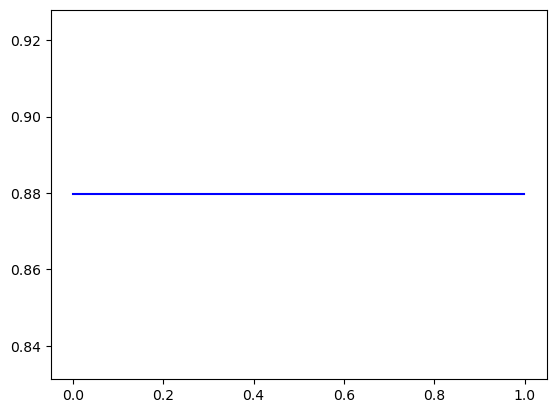

In [63]:
plt.plot(pols, TI, color='blue')